In [ ]:
%run scripts/verify_environment.py

verify_environment()

In [1]:
from datetime import datetime
from getpass import getpass

rdm_url = 'http://localhost:5001'
idp_name_1 = 'FakeCAS'
idp_username_1 = None
idp_password_1 = None
idp_name_2 = 'FakeCAS'
idp_username_2 = None
idp_password_2 = None
rdm_project_name = 'TEST-{}'.format(datetime.now().strftime('%Y%m%d-%H%M%S'))
target_storage_name = 'NII Storage'
target_storage_id = 'osfstorage'
delete_project = True
default_result_path = None
close_on_fail = False
transition_timeout = 10000

In [2]:
if idp_username_1 is None:
    idp_username_1 = input(prompt=f'Username for {idp_name_1}')
if idp_password_1 is None:
    idp_password_1 = getpass(prompt=f'Password for {idp_username_1}@{idp_name_1}')
if idp_username_2 is None:
    idp_username_2 = input(prompt=f'Username for {idp_name_2}')
if idp_password_2 is None:
    idp_password_2 = getpass(prompt=f'Password for {idp_username_2}@{idp_name_2}')
(len(idp_username_1), len(idp_password_1), len(idp_username_2), len(idp_password_2))

(29, 13, 24, 13)

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmp6hm234ek'

# Metadataアドオンの非管理者での実行

- サブシステム名: アドオン
- ページ/アドオン: Metadata
- 機能分類: メタデータ入力
- シナリオ名: 非管理者での実行
- 用意するテストデータ: URL一覧、アカウント(既存ユーザー1: GRDM、既存ユーザー2: GRDM)

## ウェブブラウザの新規プライベートウィンドウでGRDMトップページを表示する

GRDMトップページが表示されること

In [4]:
import importlib
import pandas as pd

import scripts.playwright
importlib.reload(scripts.playwright)
import scripts.metadata_v2025
importlib.reload(scripts.metadata_v2025)

from scripts.playwright import *
from scripts import grdm
from scripts.metadata_v2025 import ProjectMetadataForm, FileMetadataForm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

Start epoch: 1757106911.847261 seconds


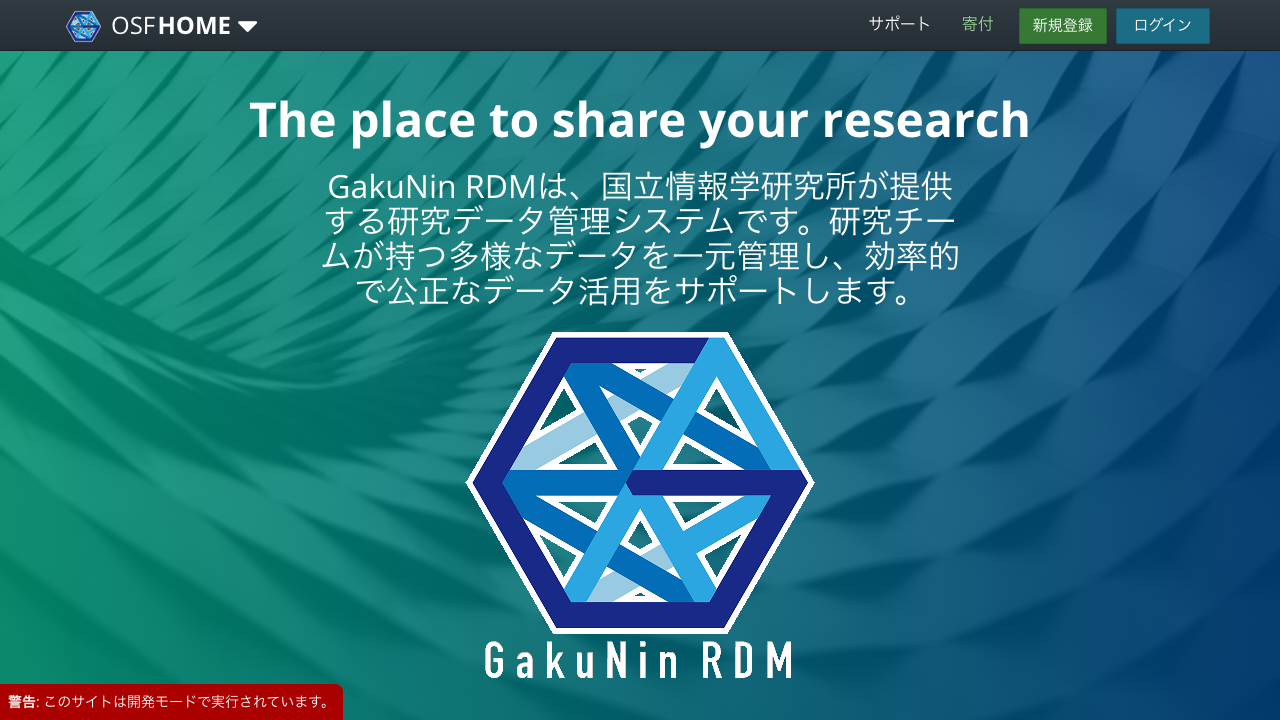

In [5]:
import time

async def _step(page):
    await page.goto(rdm_url)

    # 同意する をクリック
    await page.locator('//button[text() = "同意する"]').click()

    # 同意する が表示されなくなったことを確認
    await expect(page.locator('//button[text() = "同意する"]')).to_have_count(0, timeout=500)

await run_pw(_step)

## ログイン情報1を用いてGakuNin RDMにログインする

(IdPに関するログイン情報が与えられた場合、)
GakuNin Embeded DSのプルダウンを展開し、IdPリストから指定されたIdPを選択する。その後、アカウントのID/Passwordを入力して「Login」ボタンを押下する。

(IdPが指定されていない場合、)
CASのログイン操作を実施する。

Start epoch: 1757106916.390552 seconds


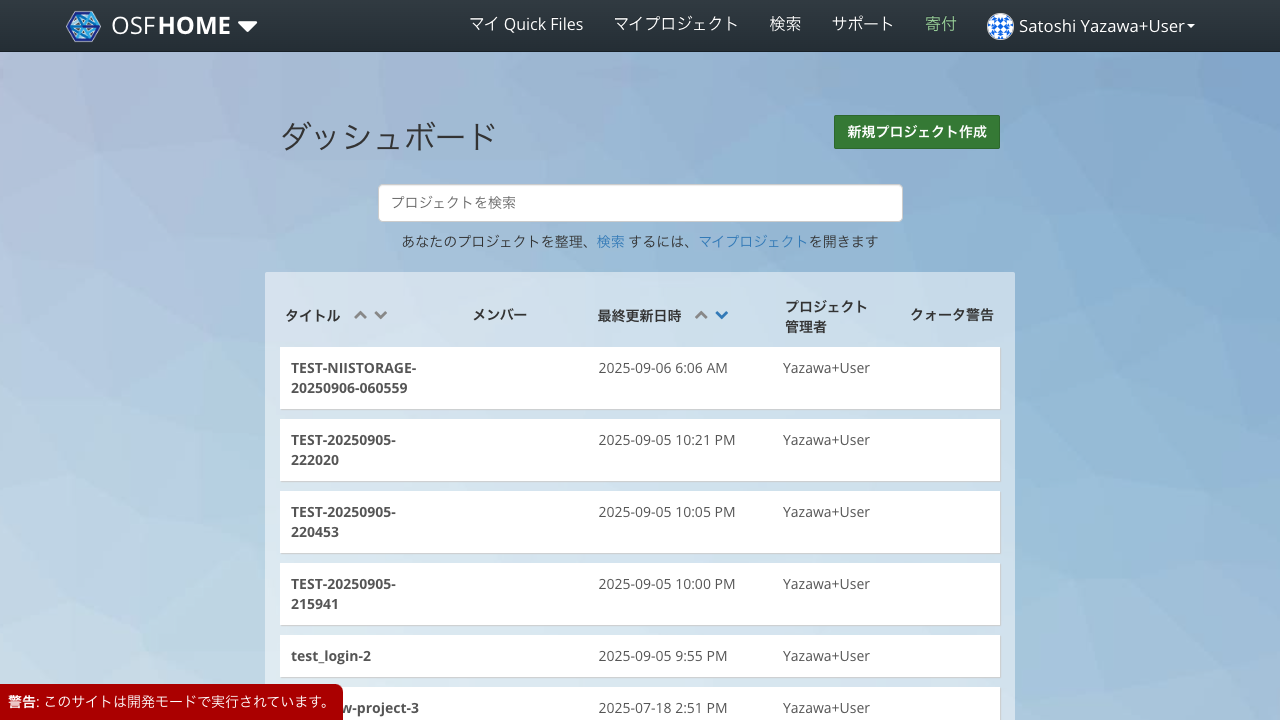

In [6]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await scripts.grdm.login(
        page, idp_name_1, idp_username_1, idp_password_1, transition_timeout=transition_timeout
    )

    # GRDMのボタンが表示されることを確認
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## プロジェクト一覧に指定されたタイトルのプロジェクトがない場合、指定された名前のプロジェクトを作成する

プロジェクト一覧に当該プロジェクト名が表示されていない場合、「新規プロジェクト作成」をクリックし、その名前を入力、「作成」をクリックする。

Start epoch: 1757106922.1723578 seconds


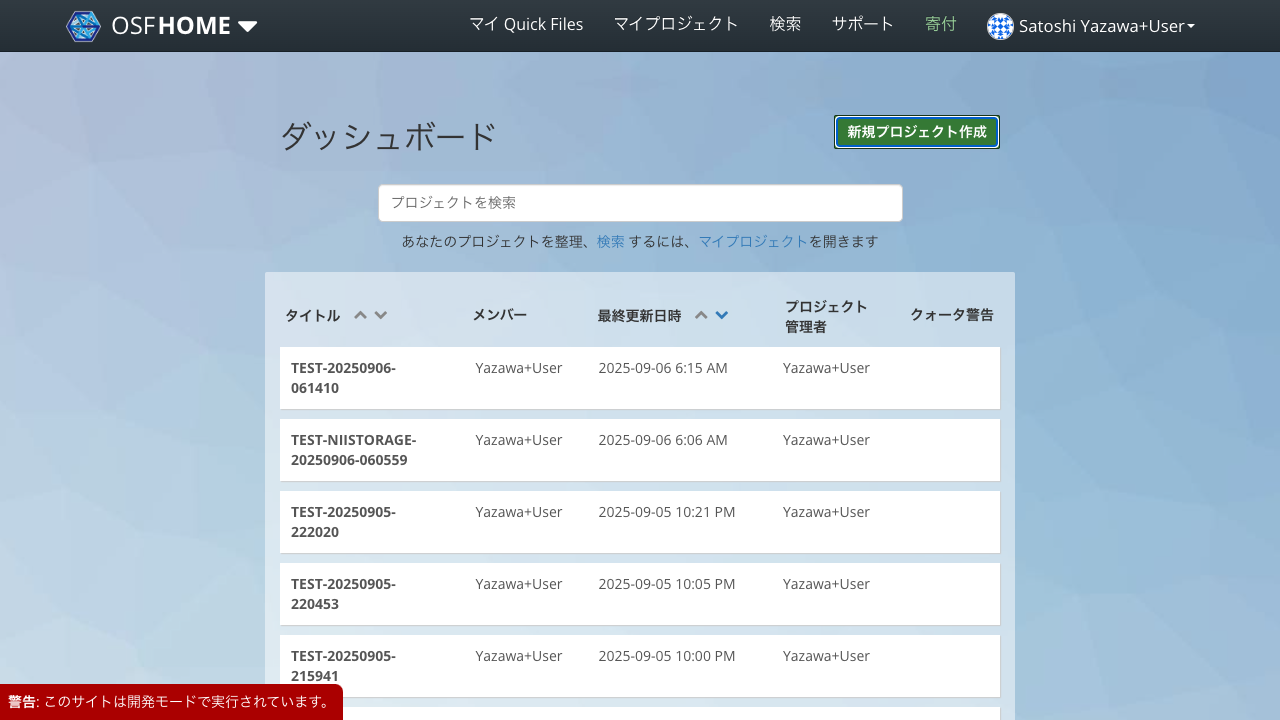

In [7]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name, transition_timeout=transition_timeout)
        
await run_pw(_step)

## ダッシュボードのプロジェクト一覧から指定されたプロジェクトをクリックする

この時、ナビゲーションバーに表示されたプロジェクトURLを控えておくこと

Start epoch: 1757106936.255241 seconds


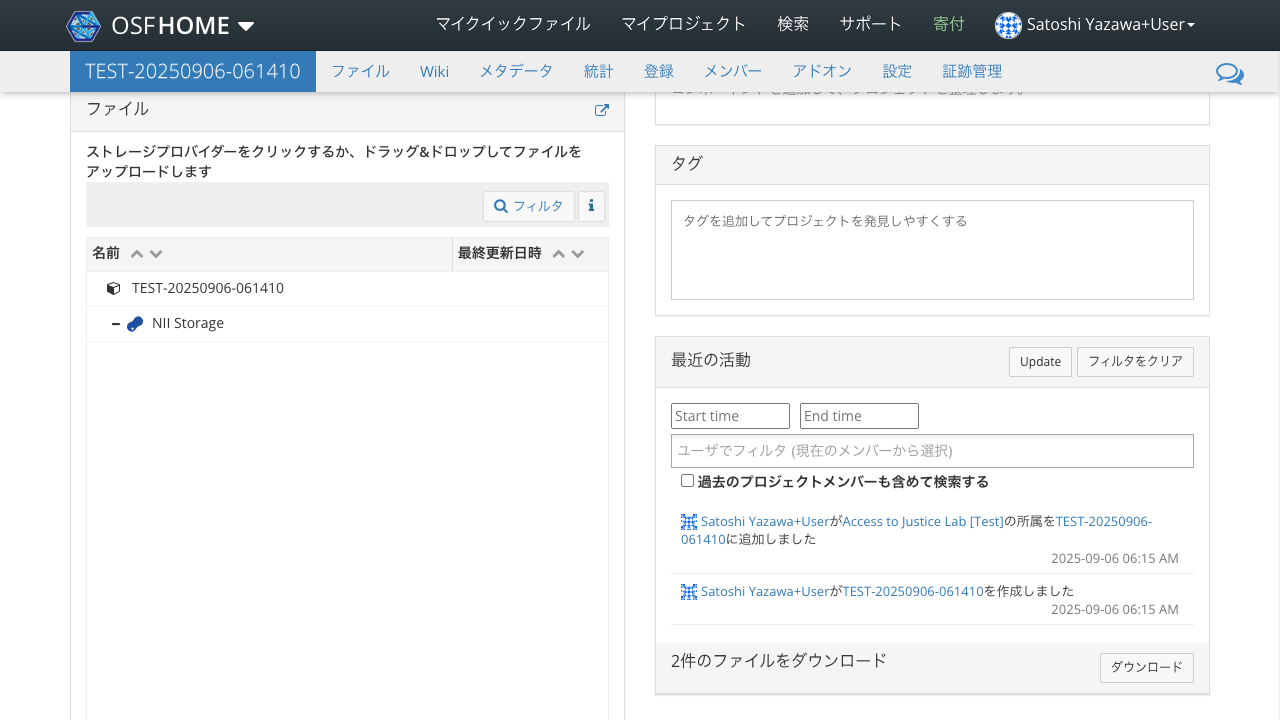

In [8]:
project_url = None
page1 = None

async def _step(page):
    await page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_name}"]').click()        

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, target_storage_name)).to_be_visible(timeout=transition_timeout)
    time.sleep(1)
    global project_url, page1
    project_url = page.url
    page1 = page

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

「アドオンを構成」のパネル内に「Metadata」の行が表示されること

Start epoch: 1757106940.2907782 seconds


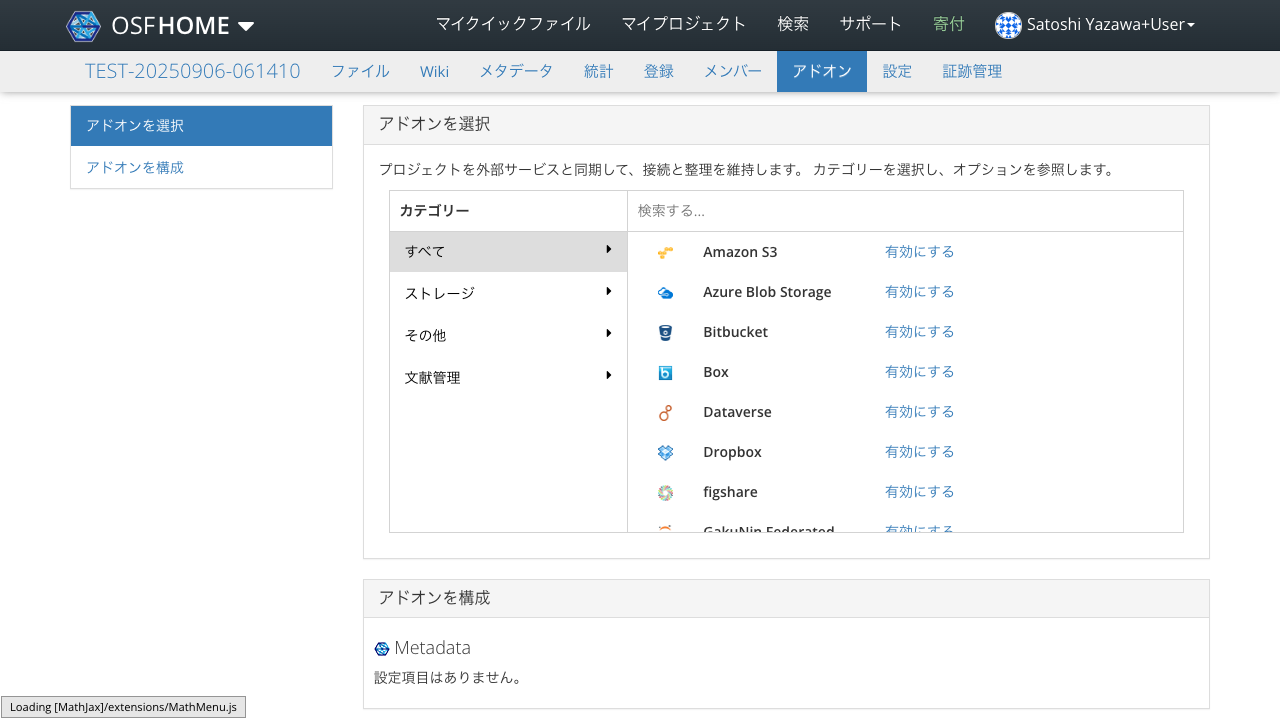

In [9]:
addon_name = 'Metadata'

async def _step(page):
    await page.locator('//a[text() = "アドオン"]').click()

    await expect(page.locator(f'//h4[@class="addon-title"][normalize-space(.)="Metadata"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## プライベートウィンドウを新規に開き、プロジェクトダッシュボードのURL/metadata を開く

ログインページが表示されること

Start epoch: 1757106950.545507 seconds


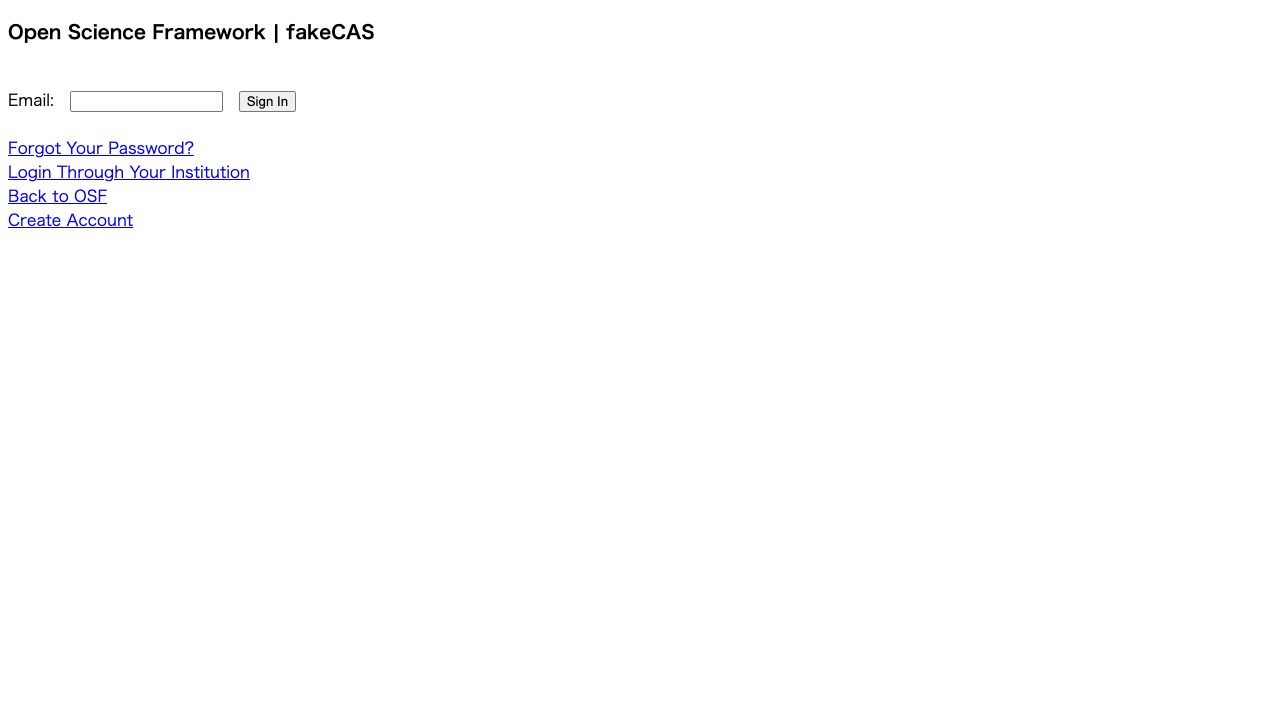

In [10]:
assert project_url.endswith('/'), project_url

async def _step(page):
    await page.goto(project_url + 'metadata')

    if idp_name_1 == 'FakeCAS':
        await expect(page.locator('#username')).to_be_editable(timeout=transition_timeout)
    else:
        await expect(page.locator('//a[@title="GakuNin RDM Sign In"]')).to_be_visible(timeout=transition_timeout)

# new_context=Trueで新規ページが開く
await run_pw(_step, new_context=True)

## ログイン情報2を用いてGakuNin RDMにログインする

(IdPに関するログイン情報が与えられた場合、)
GakuNin Embeded DSのプルダウンを展開し、IdPリストから指定されたIdPを選択する。その後、アカウントのID/Passwordを入力して「Login」ボタンを押下する。

(IdPが指定されていない場合、)
CASのログイン操作を実施する。

「許可が必要です」画面が表示されること

Start epoch: 1747695669.927474 seconds


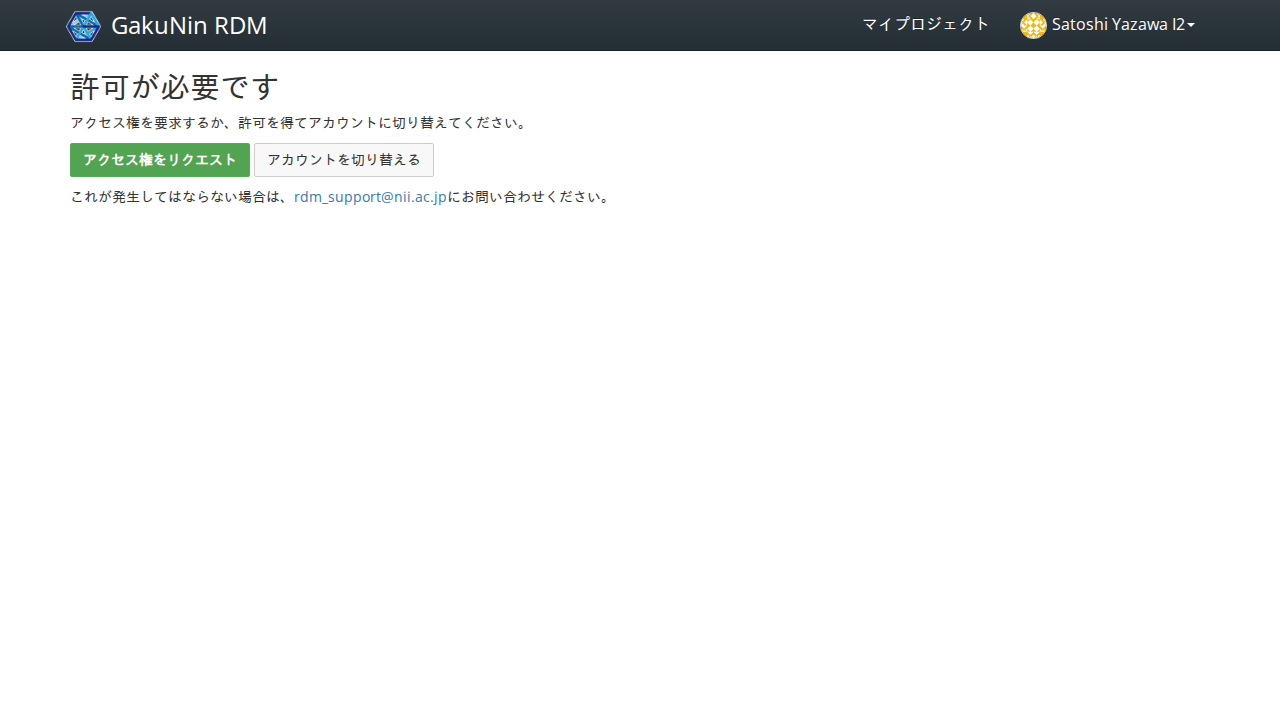

In [13]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await scripts.grdm.login(
        page, idp_name_2, idp_username_2, idp_password_2, transition_timeout=transition_timeout
    )

    await expect(page.locator('//button[text() = "アクセス権をリクエスト"]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 「アクセス権をリクエスト」をクリックする



Start epoch: 1747695671.483917 seconds


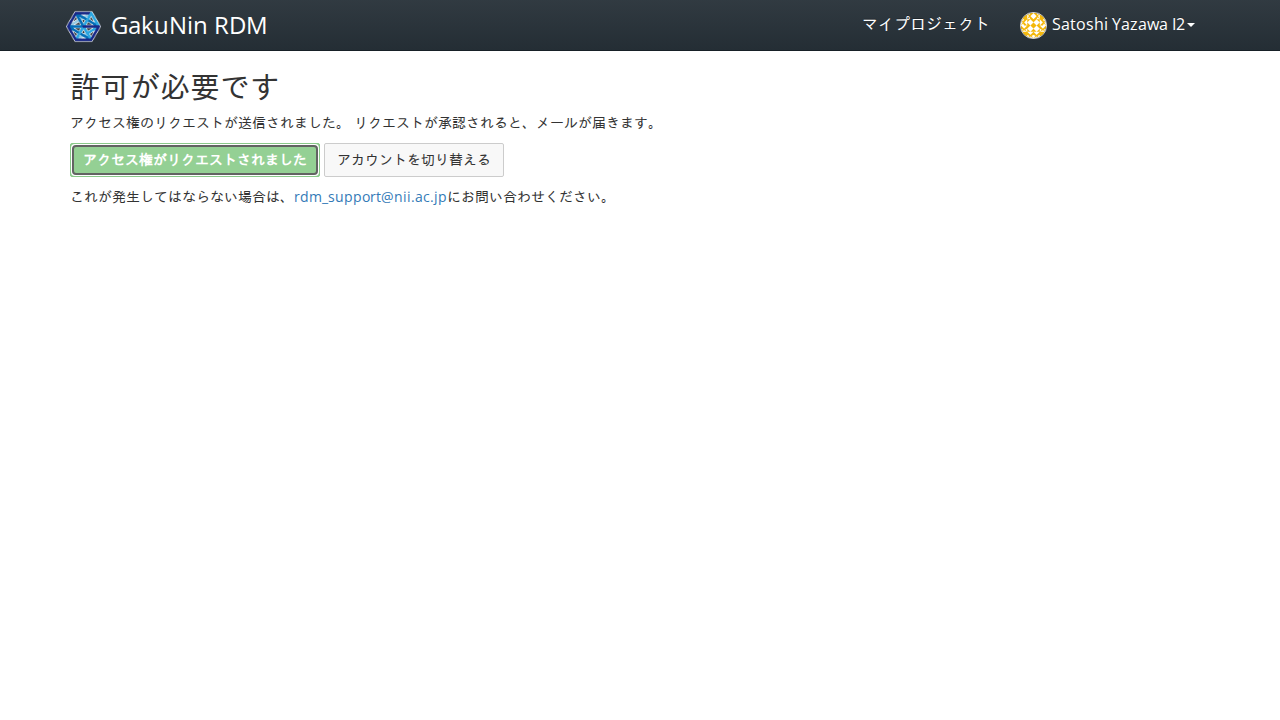

In [14]:
async def _step(page):
    await page.locator('//button[text() = "アクセス権をリクエスト"]').click()

    await expect(page.locator('//button[text() = "アクセス権がリクエストされました"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 1つ前のタブで「メンバー」をクリックする

Start epoch: 1747695672.04672 seconds


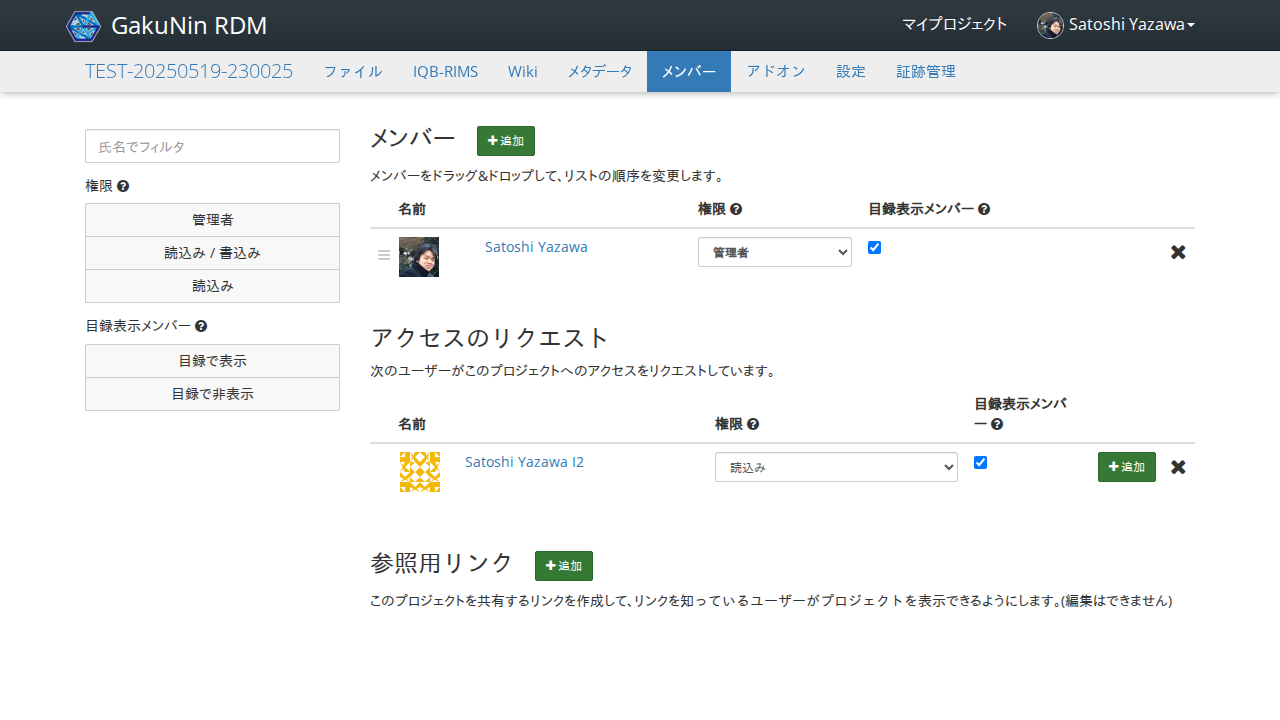

In [15]:
async def _step(page):
    await page1.locator("#projectSubnav").get_by_role("link", name="メンバー").click()

    await expect(page1.locator('//h3[contains(text(), "アクセスのリクエスト")]')).to_be_visible(timeout=transition_timeout)
    await expect(page1.locator('.request-accept-button')).to_be_enabled(timeout=transition_timeout)
    return page1 #画面キャプチャ等以降の操作はpage1で

await run_pw(_step)

## 権限を「読込み/書込み」に変更し、「追加」をクリックする

Start epoch: 1747695673.1351147 seconds


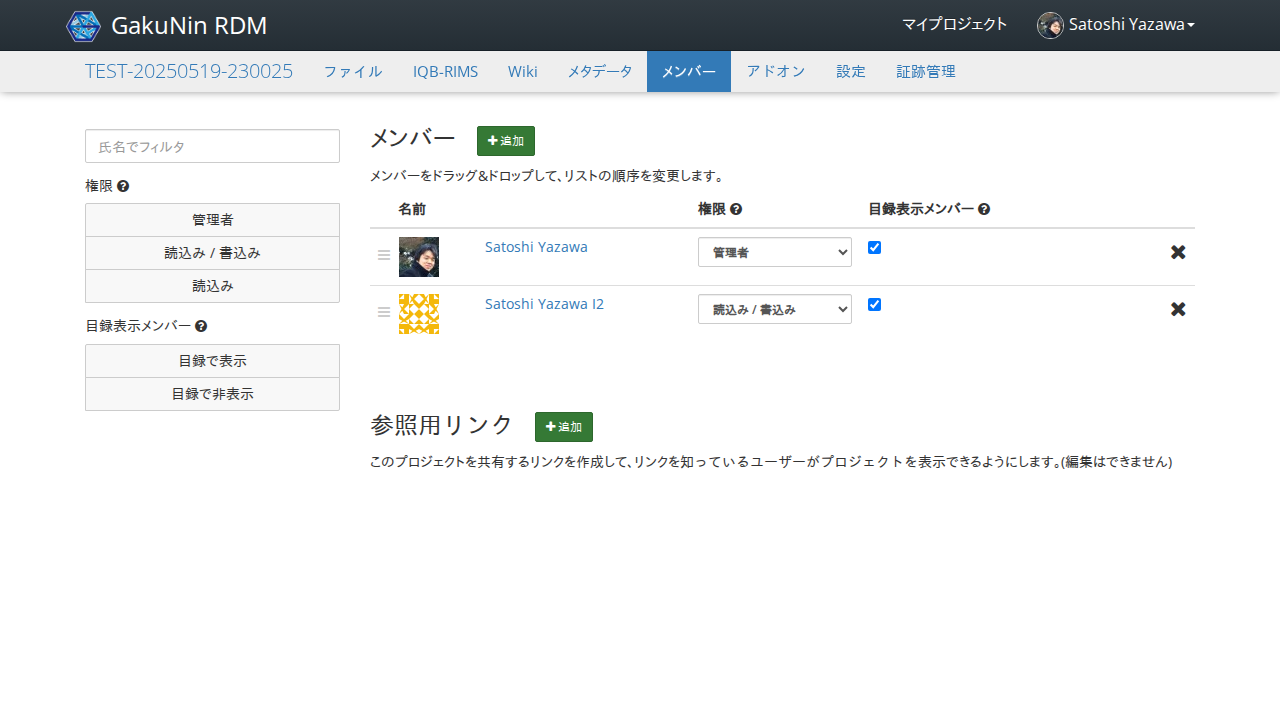

In [16]:
async def _step(page):
    await page.locator("#manageAccessRequests .permissions select").select_option('write')

    await page.locator('.request-accept-button').click()
    await expect(page.locator("#manageAccessRequests .permissions select")).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)

## 前のタブに戻り、再読み込みする

メタデータの一覧ページが表示されること

Start epoch: 1747695675.4248047 seconds


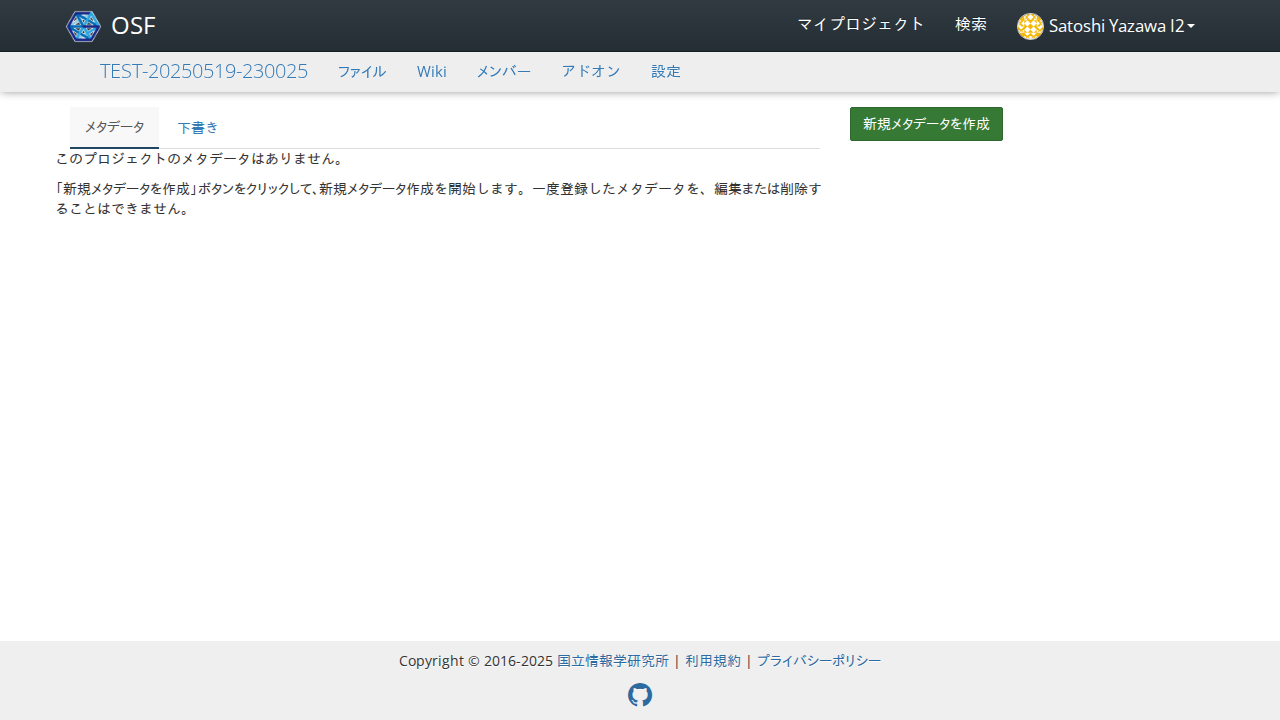

In [ ]:
await close_latest_page()

async def _step(page):
    await page.reload()
    await expect(page.locator('//*[@data-test-new-metadata-button]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「新規メタデータ」をクリックする

スキーマ選択ダイアログが表示されること

In [ ]:
async def _step(page):
    await page.locator('//*[@data-test-new-metadata-button]').click()

    await expect(page.locator('//*[@data-test-new-report-modal-schema="公的資金による研究データのメタデータ登録"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//*[@data-test-new-report-modal-create-report-button]')).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)

## 「メタデータを作成」をクリックする

メタデータ編集ウィンドウが表示されること

In [ ]:
async def _step(page):
    await page.locator('//*[@data-test-new-report-modal-create-report-button]').click()

    form = ProjectMetadataForm(page)
    await expect(form.get_locator('資金配分機関情報').locator('.ember-power-select-status-icon')).to_be_attached(timeout=transition_timeout)
    await expect(form.get_locator('体系的番号におけるプログラム情報コード')).to_be_editable(timeout=1000)
    await expect(form.get_locator('プログラム名 (日本語)')).to_be_editable(timeout=1000)
    await expect(form.get_locator('Program name (English)')).to_be_editable(timeout=1000)
    await expect(form.get_locator('体系的番号')).to_be_editable(timeout=1000)
    await expect(form.get_locator('プロジェクト名 (日本語)')).to_be_editable(timeout=1000)
    await expect(form.get_locator('Project name (English)')).to_be_editable(timeout=1000)
    await expect(form.get_locator('プロジェクトの分野').locator('.ember-power-select-status-icon')).to_be_attached(timeout=1000)

await run_pw(_step)

## 「資金配分機関情報」をクリックする

「国立研究開発法人科学技術振興機構 | JST」ほか選択肢が表示されること

In [20]:
async def _step(page):
    form = ProjectMetadataForm(page)
    await form.fill('資金配分機関情報', '国立研究開発法人科学技術振興機構 | JST')

    await expect(form.get_locator('資金配分機関情報').locator('.ember-power-select-selected-item')).to_have_text('JST', timeout=transition_timeout)

await run_pw(_step)

##  「国立研究開発法人科学技術振興機構 | JST」 をクリックする

「JST」が値に設定されること

In [21]:
# 資金配分機関情報の選択はcell 32に統合済み
pass

## 「体系的番号におけるプログラム情報コード」に「ABC」を入力する

テキストフィールドに値が表示されること

In [22]:
async def _step(page):
    form = ProjectMetadataForm(page)
    await form.fill('体系的番号におけるプログラム情報コード', 'ABC')

    await expect(form.get_locator('体系的番号におけるプログラム情報コード')).to_have_value('ABC', timeout=transition_timeout)

await run_pw(_step)

## 「プログラム名 (日本語)」に「サンプルプログラム」を入力する

テキストフィールドに値が表示されること

In [23]:
async def _step(page):
    form = ProjectMetadataForm(page)
    await form.fill('プログラム名 (日本語)', 'サンプルプログラム')

    await expect(form.get_locator('プログラム名 (日本語)')).to_have_value('サンプルプログラム', timeout=transition_timeout)

await run_pw(_step)

## 「Program name (English)」に「Sample Program」を入力する

テキストフィールドに値が表示されること

In [24]:
async def _step(page):
    form = ProjectMetadataForm(page)
    await form.fill('Program name (English)', 'Sample Program')

    await expect(form.get_locator('Program name (English)')).to_have_value('Sample Program', timeout=transition_timeout)

await run_pw(_step)

## 「体系的番号」をクリックする

テキストフィールドが表示されること

In [25]:
async def _step(page):
    form = ProjectMetadataForm(page)
    await form.fill('体系的番号', '0123456789')

    await expect(form.get_locator('体系的番号')).to_have_value('0123456789', timeout=transition_timeout)

await run_pw(_step)

##  「0123456789(ENTER)」 を入力する

「0123456789」が値に設定されること

Start epoch: 1747695683.5921223 seconds


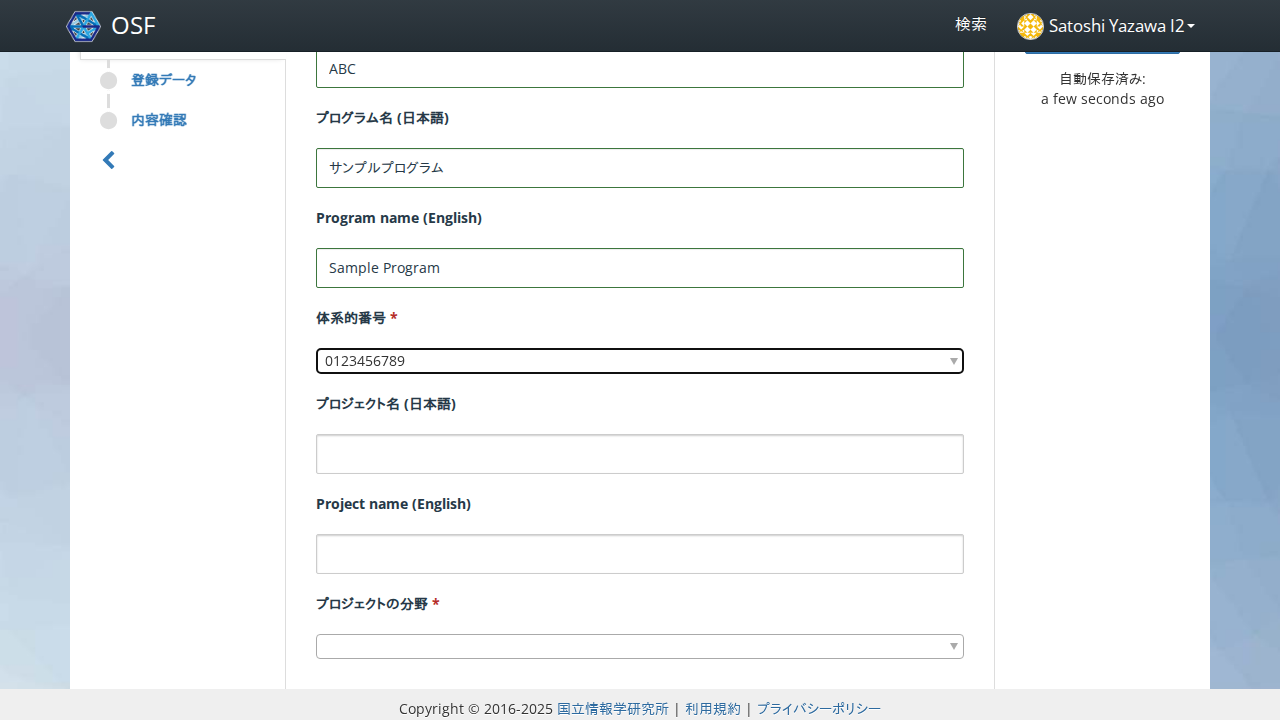

In [26]:
# 体系的番号の入力はcell 42に統合済み
pass


## 「プロジェクト名 (日本語)」に「サンプルメタデータプロジェクト」を入力する

テキストフィールドに値が表示されること

In [27]:
async def _step(page):
    form = ProjectMetadataForm(page)
    await form.fill('プロジェクト名 (日本語)', 'サンプルメタデータプロジェクト')

    await expect(form.get_locator('プロジェクト名 (日本語)')).to_have_value('サンプルメタデータプロジェクト', timeout=transition_timeout)

await run_pw(_step)

## 「Project name (English)」に「Sample Metadata Project」を入力する

テキストフィールドに値が表示されること

In [28]:
async def _step(page):
    form = ProjectMetadataForm(page)
    await form.fill('Project name (English)', 'Sample Metadata Project')

    await expect(form.get_locator('Project name (English)')).to_have_value('Sample Metadata Project', timeout=transition_timeout)

await run_pw(_step)

## 「プロジェクトの分野」をクリックする

テキストフィールドが表示されること

In [29]:
async def _step(page):
    form = ProjectMetadataForm(page)
    await form.fill('プロジェクトの分野', '情報通信 | 289')

    await expect(form.get_locator('プロジェクトの分野').locator('.ember-power-select-selected-item')).to_have_text('289', timeout=transition_timeout)

await run_pw(_step)

##  「情報通信 | 289」 をクリックする

「289」が値に設定されること

In [30]:
# プロジェクトの分野の選択はcell 50に統合済み
pass

## 「次へ」をクリックする

左側ペイン「メタデータ登録」が緑色かつチェックマークが表示されること

In [31]:
import re

async def _step(page):
    await page.locator('//*[@data-test-goto-next-page]').click()
    
    await expect(page.locator('//span[@data-test-label and text() = "助成情報登録"]/../preceding-sibling::i')).to_have_class(re.compile(r'.*fa-check-circle-o.*'), timeout=transition_timeout)

await run_pw(_step)

## 「内容確認」をクリックする

左側ペイン「登録データ」が赤色かつ！マークが表示されること

In [32]:
async def _step(page):
    await page.locator('//*[@data-test-goto-review]').click()
    
    await expect(page.locator('//span[@data-test-label and text() = "登録データ"]/../preceding-sibling::i')).to_have_class(re.compile(r'.*fa-check-circle-o.*'), timeout=transition_timeout)

await run_pw(_step)

## 「登録データ一覧」編集ボタンをクリックする

「登録データ」編集画面が表示されること

Start epoch: 1747695685.3980925 seconds


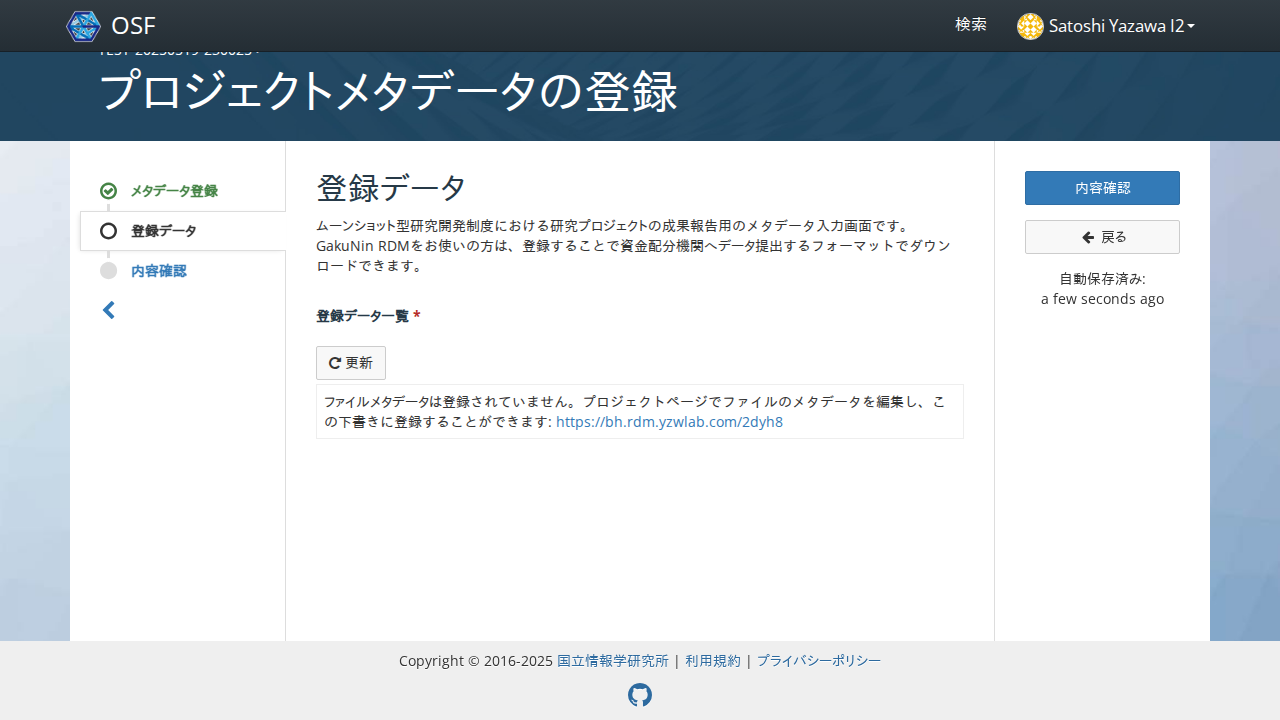

In [33]:
async def _step(page):
    await page.locator('//*[@aria-label="Edit 登録データ一覧|Registered Data List"]').click()
    
    await expect(page.locator(f'//a[starts-with(@href, "{rdm_url}") and @target = "_blank"]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 「登録データ一覧」の説明中のURLをクリックする

プロジェクトダッシュボードが表示されること

Start epoch: 1747695685.6617682 seconds


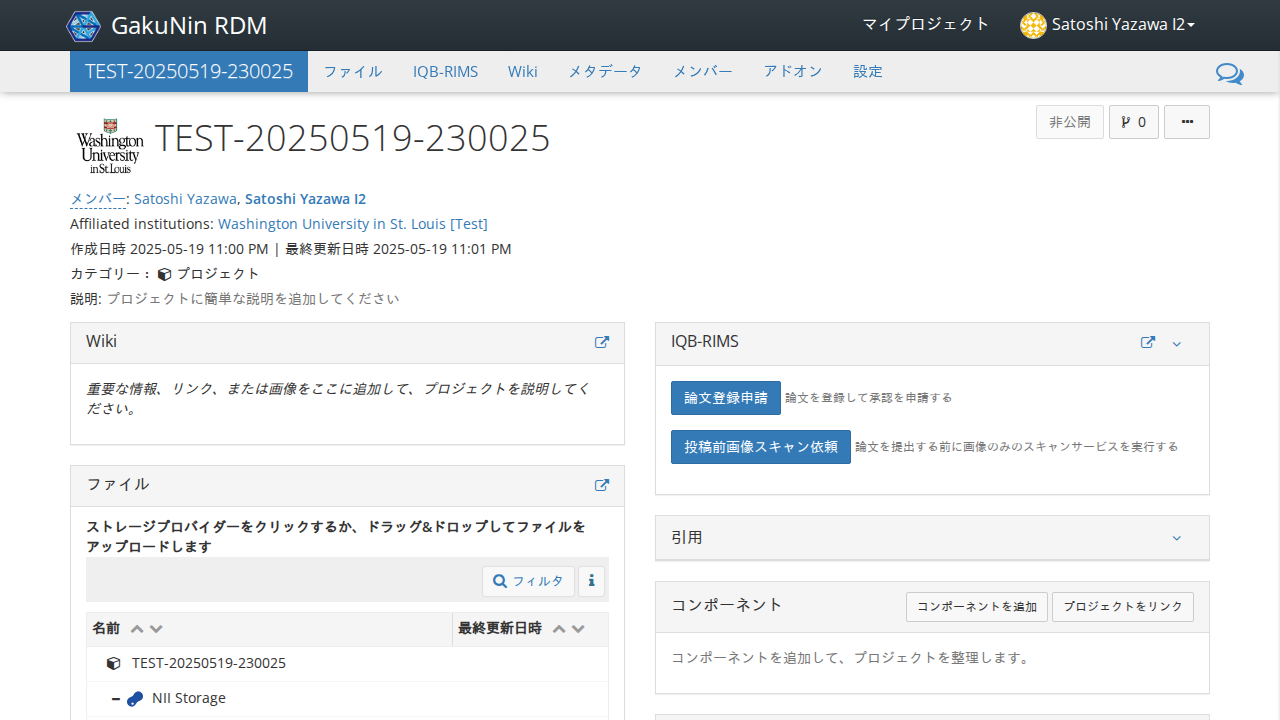

In [34]:
async def _step(page):
    popup_future = page.wait_for_event('popup')
    await page.locator(f'//a[starts-with(@href, "{rdm_url}") and @target = "_blank"]').click()
    popup = await popup_future
    
    await expect(popup.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=30000)
    await expect(grdm.get_select_expanded_storage_title_locator(popup, target_storage_name)).to_be_visible(timeout=transition_timeout)
    time.sleep(1)
    return popup

await run_pw(_step)

## 対象ストレージをクリックする

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

Start epoch: 1747695690.0765886 seconds


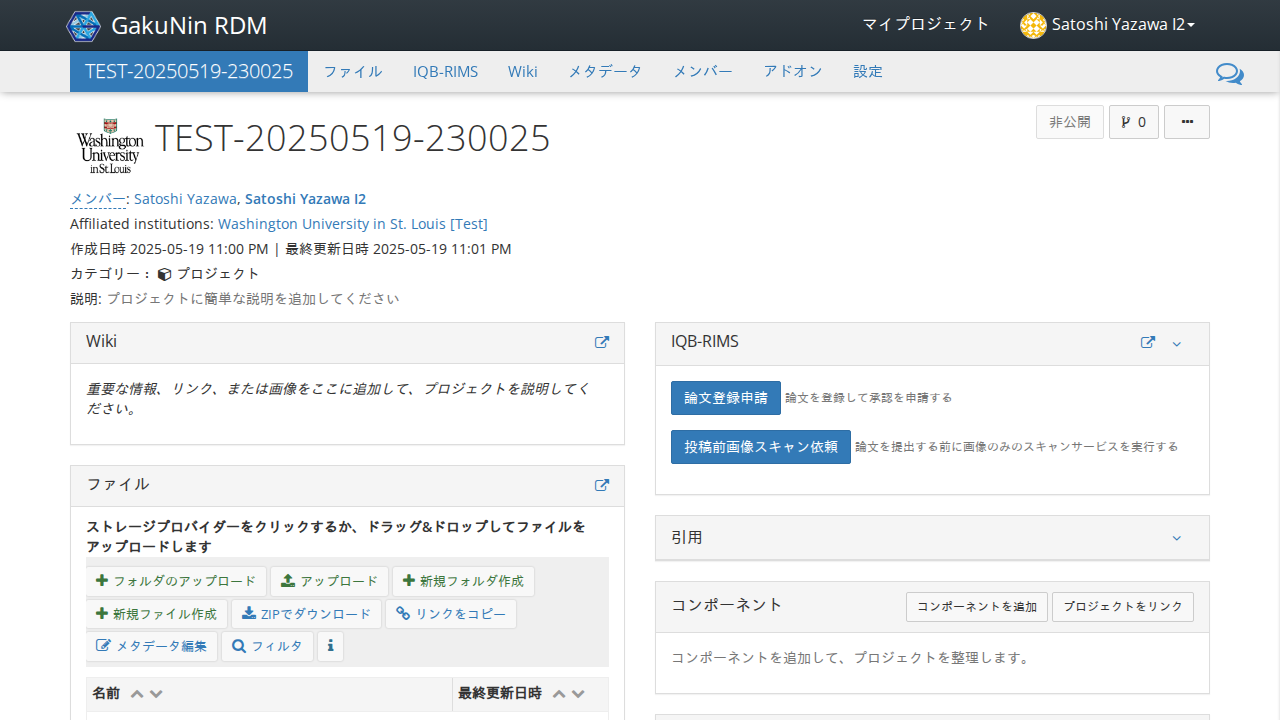

In [35]:
async def _step(page):
    await grdm.get_select_expanded_storage_title_locator(page, target_storage_name).click()
    
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 「新規フォルダ作成」をクリックする

フォルダ名入力テキストフィールドが表示されること

Start epoch: 1747695690.311856 seconds


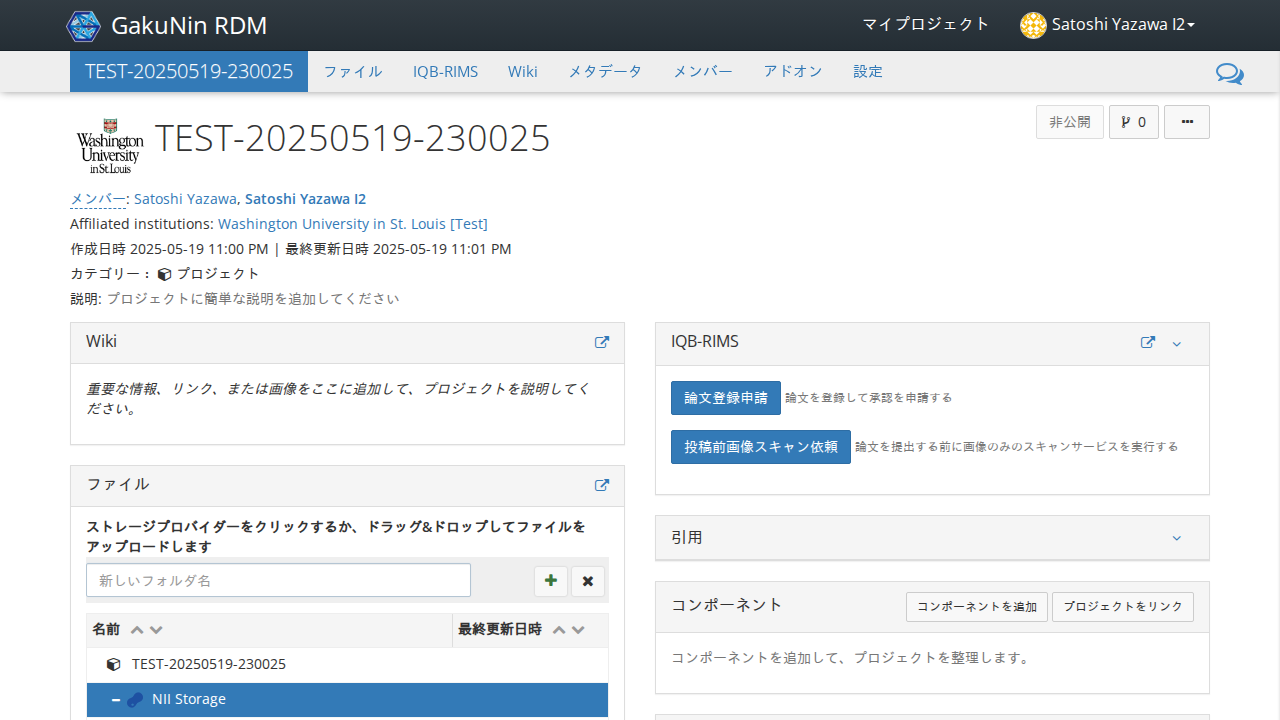

In [36]:
async def _step(page):
    await page.locator('//*[text() = "新規フォルダ作成"]').click()
    
    await expect(page.locator('//input[@id = "createFolderInput"]')).to_be_editable(timeout=transition_timeout)

await run_pw(_step)

## 「TESTMETADATA(ENTER)」を入力する

TESTMETADATAフォルダが作成されること

Start epoch: 1747695690.53322 seconds


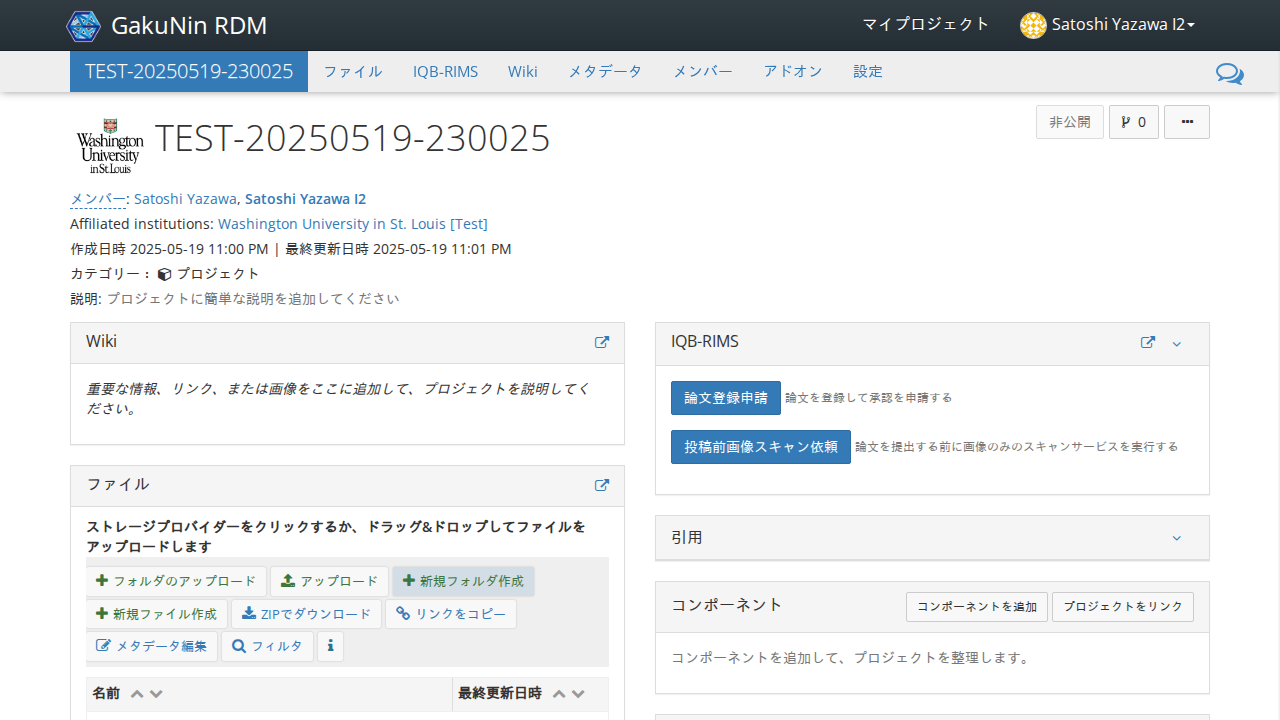

In [37]:
async def _step(page):
    await page.locator('//input[@id = "createFolderInput"]').fill('TESTMETADATA')
    await page.keyboard.press('Enter')

    await expect(page.locator('//*[text() = "TESTMETADATA"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「TESTMETADATA」をクリックする

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

Start epoch: 1747695692.6599329 seconds


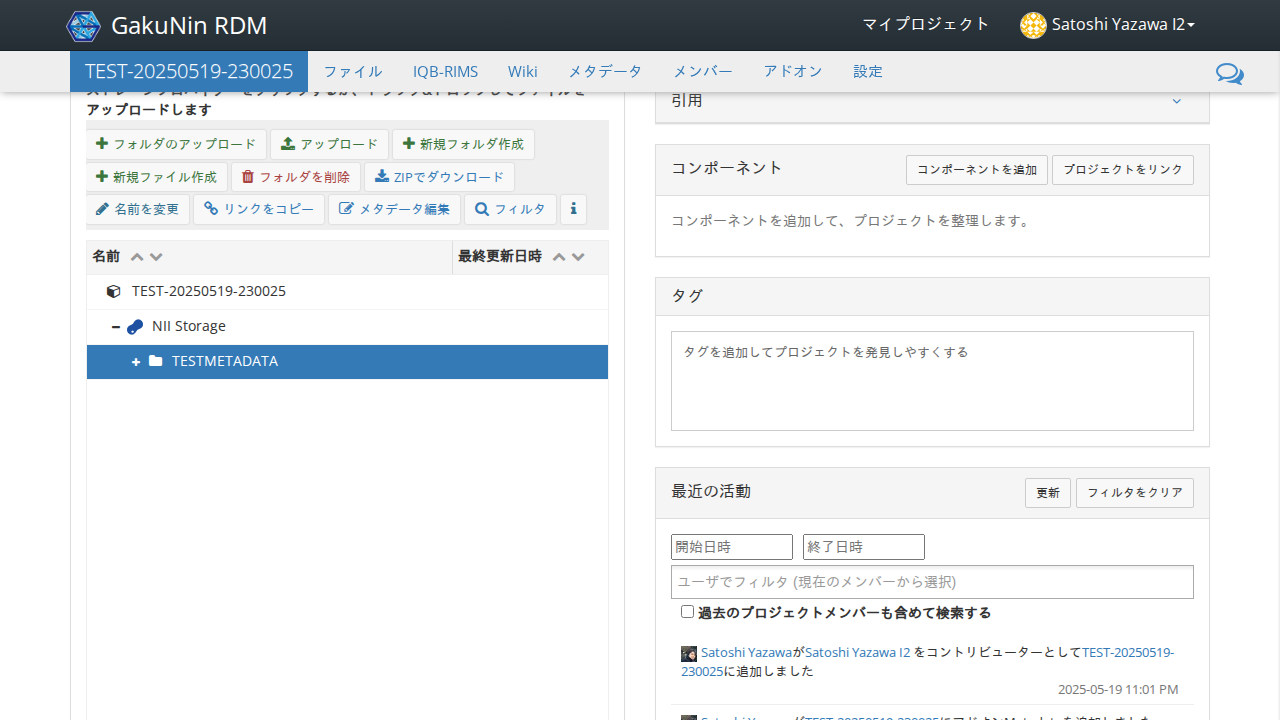

In [38]:
async def _step(page):
    await page.locator('//*[text() = "TESTMETADATA"]').click()

    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

##  「メタデータ編集」をクリックする

「メタデータ編集」ダイアログが表示されること

Start epoch: 1747695692.8811598 seconds


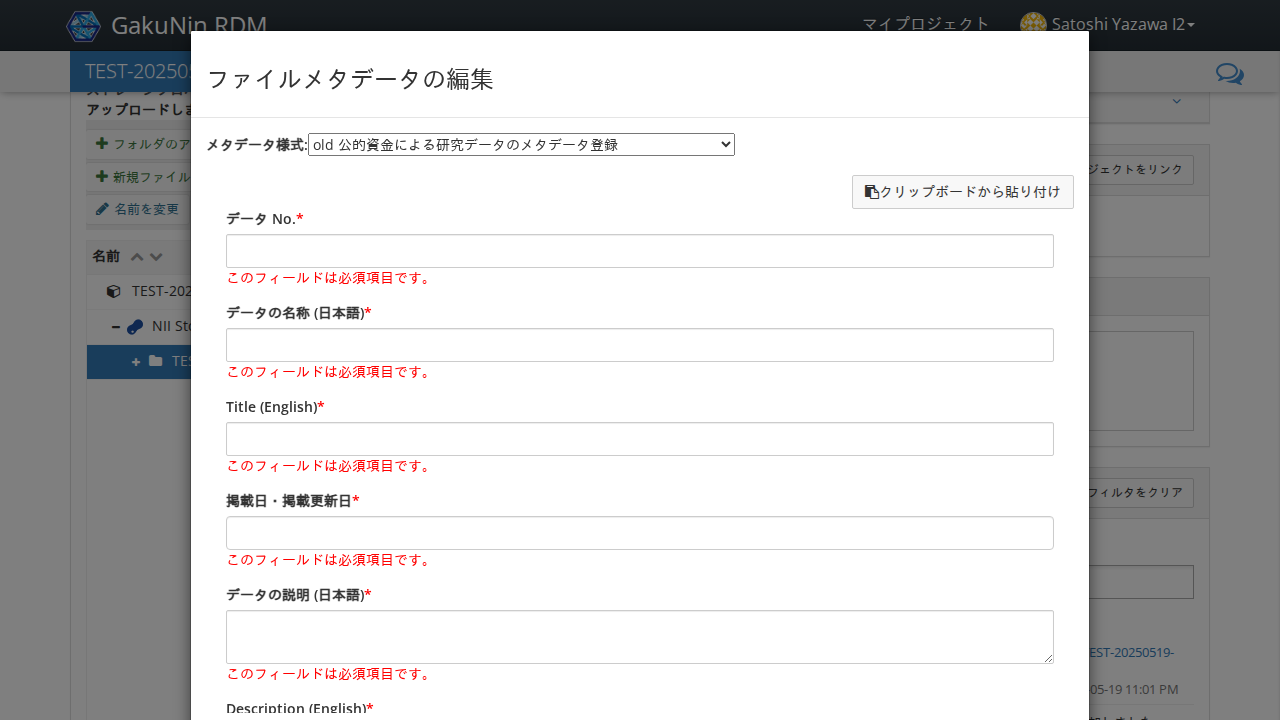

In [39]:
async def _step(page):
    await page.locator('//*[text() = "メタデータ編集"]').click()

    await expect(page.locator('//label[contains(text(), "メタデータ様式")]/following-sibling::select')).to_be_editable(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)

##  「メタデータ様式」に「研究成果（公的資金対応）のメタデータ登録」を入力する

「データNo.」フィールドが表示されること

In [40]:
async def _step(page):
    await page.locator('//label[contains(text(), "メタデータ様式")]/following-sibling::select').select_option('研究成果（公的資金対応）のメタデータ登録')

    form = FileMetadataForm(page)
    await expect(form.get_locator('データ No.')).to_be_editable(timeout=transition_timeout)

await run_pw(_step)

##  「データ No.」の「入力」をクリックする

データNo.にファイルパスが表示されること

In [41]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill("データ No.", f"files/dir/{target_storage_id}/TESTMETADATA/")

    await expect(form.get_locator("データ No.")).to_have_value(f"files/dir/{target_storage_id}/TESTMETADATA/", timeout=transition_timeout)

await run_pw(_step)

##  「データの名称(日本語)」に「テストデータ」を入力する

「このフィールドか「Title(English)」フィールドのいずれかを入力する必要があります。」が表示されなくなること

In [42]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('データの名称 (日本語)', 'テストデータ')
    await page.keyboard.press('Enter')

    await expect(form.get_locator('データの名称 (日本語)')).to_have_value('テストデータ', timeout=transition_timeout)

await run_pw(_step)

##  「Data title (English)」に「Test Data」を入力する

入力した値が表示されること

In [43]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('Data title (English)', 'Test Data')
    await page.keyboard.press('Enter')

    await expect(form.get_locator('Data title (English)')).to_have_value('Test Data', timeout=transition_timeout)

await run_pw(_step)

##  「掲載日・掲載更新日」に「2022-05-25」を入力する

入力した値が表示されること

In [44]:
async def _step(page):
    form = FileMetadataForm(page)
    locator = form.get_locator('掲載日・掲載更新日')
    await locator.focus()
    await page.keyboard.type('2022-05-25')
    await page.keyboard.press('Tab')

    await expect(locator).to_have_value('2022-05-25', timeout=transition_timeout)

await run_pw(_step)

##  「データの説明 (日本語)」に「自動テストによって作成されたメタデータです。」を入力する

「このフィールドか「Description(English)」フィールドのいずれかを入力する必要があります。」が表示されなくなること

In [45]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('データの説明 (日本語)', '自動テストによって作成されたメタデータです。')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('データの説明 (日本語)')).to_have_value('自動テストによって作成されたメタデータです。', timeout=transition_timeout)

await run_pw(_step)

##  「Description (English)」に「Metadata created by automated testing.」を入力する

入力した値が表示されること

In [46]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('Description (English)', 'Metadata created by automated testing.')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('Description (English)')).to_have_value('Metadata created by automated testing.', timeout=transition_timeout)

await run_pw(_step)

##  「概略データ量」の「計算」をクリックする

「0B」と入力されること

In [47]:
async def _step(page):
    await page.locator("//label[contains(text(), '概略データ量')]/../following-sibling::div[1]//*[text() = '計算']").click()
    form = FileMetadataForm(page)

    await expect(form.get_locator("概略データ量")).to_have_value("0B", timeout=transition_timeout)

await run_pw(_step)

##  「管理対象データの利活用・提供方針 (有償/無償)」に「無償」を入力する

「このフィールドは必須項目です。」が表示されなくなること

In [48]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('管理対象データの利活用・提供方針 (有償/無償)', '無償')

    await expect(form.get_locator('管理対象データの利活用・提供方針 (有償/無償)').locator('input[type="radio"]:checked + span, label:has(input[type="radio"]:checked)')).to_contain_text('無償', timeout=transition_timeout)

await run_pw(_step)

##  「管理対象データの利活用・提供方針 (ライセンス)」に「CC BY 4.0 表示 国際」を入力する

「このフィールドは必須項目です。」が表示されなくなること

In [49]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('管理対象データの利活用・提供方針 (ライセンス)', 'CC BY 4.0 表示 国際')

    await expect(form.get_locator('管理対象データの利活用・提供方針 (ライセンス)').locator('option:checked')).to_have_text('CC BY 4.0 表示 国際', timeout=transition_timeout)

await run_pw(_step)

##  「管理対象データの利活用・提供方針 (引用方法等・日本語)」に「利用方針をここに記載します。」を入力する

「このフィールドか「Data utilization and provision policy (citation information, English)」フィールドのいずれかを入力する必要があります。」が表示されなくなること

In [50]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('管理対象データの利活用・提供方針 (引用方法等・日本語)', '利用方針をここに記載します。')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('管理対象データの利活用・提供方針 (引用方法等・日本語)')).to_have_value('利用方針をここに記載します。', timeout=transition_timeout)

await run_pw(_step)

##  「Data utilization and provision policy (citation information, English)」に「The policy for use is described here.」を入力する

入力した値が表示されること

In [51]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('Data utilization and provision policy (citation information, English)', 'The policy for use is described here.')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('Data utilization and provision policy (citation information, English)')).to_have_value('The policy for use is described here.', timeout=transition_timeout)

await run_pw(_step)

##  「アクセス権」に「公開」を入力する

「このフィールドは必須項目です。」が表示されなくなること

In [52]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('アクセス権', '公開')

    await expect(form.get_locator('アクセス権').locator('option:checked')).to_have_text('公開', timeout=transition_timeout)

await run_pw(_step)

##  「リポジトリ情報 (日本語)」に「テストリポジトリ」を入力する

入力した値が表示されること

In [53]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('リポジトリ情報 (日本語)', 'テストリポジトリ')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('リポジトリ情報 (日本語)')).to_have_value('テストリポジトリ', timeout=transition_timeout)

await run_pw(_step)

##  「Repository information (English)」に「Test Repository」を入力する

入力した値が表示されること

In [54]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('Repository information (English)', 'Test Repository')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('Repository information (English)')).to_have_value('Test Repository', timeout=transition_timeout)

await run_pw(_step)

##  「リポジトリURL・DOIリンク」の「入力」をクリックする

フォルダのURLが表示されること

In [ ]:
from urllib.parse import urljoin

async def _step(page):
    form = FileMetadataForm(page)
    input_locator = form.get_locator("リポジトリURL・DOIリンク")
    await page.locator("//label[contains(text(), 'リポジトリURL・DOIリンク')]/../following-sibling::div[1]//*[text() = 'GakuNin RDM URL入力']").click()
    value = urljoin(page.url, f"files/dir/{target_storage_id}/TESTMETADATA/")

    await expect(input_locator).to_have_value(value, timeout=transition_timeout)

await run_pw(_step)

##  「データ作成者」の「追加」をクリックする

作成者入力フィールドが表示されること

In [56]:
async def _step(page):
    form = FileMetadataForm(page)
    container = form.get_locator('データ作成者')
    panel = container.locator('tr.metadata-edit-mode')
    erad_input = panel.locator('xpath=.//label[contains(text(), "e-Rad 研究者番号")]/following-sibling::div[1]//input')

    await expect(erad_input).to_be_editable(timeout=transition_timeout)

await run_pw(_step)

##  「e-Rad研究者番号」に「0123456789」を入力する

フィールドに値が表示されること

In [57]:
async def _step(page):
    form = FileMetadataForm(page)
    container = form.get_locator('データ作成者')
    panel = container.locator('tr.metadata-edit-mode')
    erad_input = panel.locator('xpath=.//label[contains(text(), "e-Rad 研究者番号")]/following-sibling::div[1]//input')
    await erad_input.fill('0123456789')

    await expect(erad_input).to_have_value('0123456789', timeout=transition_timeout)

await run_pw(_step)

##  「名前　(日本語)」に「情報太郎」を入力する

フィールドに値が表示されること

In [58]:
async def _step(page):
    form = FileMetadataForm(page)
    container = form.get_locator('データ作成者')
    panel = container.locator('tr.metadata-edit-mode')
    ja_table = panel.locator('xpath=.//table[.//th[text()="姓"]]')
    await ja_table.locator('tbody td:nth-of-type(1) input').fill('情報')
    await ja_table.locator('tbody td:nth-of-type(3) input').fill('太郎')

    await expect(ja_table.locator('tbody td:nth-of-type(1) input')).to_have_value('情報', timeout=transition_timeout)
    await expect(ja_table.locator('tbody td:nth-of-type(3) input')).to_have_value('太郎', timeout=transition_timeout)

await run_pw(_step)

##  「Name(English)」に「Taro Joho」を入力する

フィールドに値が表示されること

In [59]:
async def _step(page):
    form = FileMetadataForm(page)
    container = form.get_locator('データ作成者')
    panel = container.locator('tr.metadata-edit-mode')
    en_table = panel.locator('xpath=.//table[.//th[text()="Last Name"]]')
    await en_table.locator('tbody td:nth-of-type(1) input').fill('Joho')
    await en_table.locator('tbody td:nth-of-type(3) input').fill('Taro')

    await expect(en_table.locator('tbody td:nth-of-type(1) input')).to_have_value('Joho', timeout=transition_timeout)
    await expect(en_table.locator('tbody td:nth-of-type(3) input')).to_have_value('Taro', timeout=transition_timeout)

    await panel.locator('.hide-edit-row').click()

await run_pw(_step)

##  「データ管理機関 (日本語)」に「国立情報学研究所」を入力する

「このフィールドか「Hosting institution (English)」フィールドのいずれかを入力する必要があります。」が表示されなくなること

In [60]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('データ管理機関 (日本語)', '国立情報学研究所')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('データ管理機関 (日本語)')).to_have_value('国立情報学研究所', timeout=transition_timeout)

await run_pw(_step)

##  「Hosting institution (English)」に「National Institute of Informatics」を入力する

入力した値が表示されること

In [61]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('Hosting institution (English)', 'National Institute of Informatics')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('Hosting institution (English)')).to_have_value('National Institute of Informatics', timeout=transition_timeout)

await run_pw(_step)

## 「データ管理機関コード」に「 https://ror.org/DUMMY 」を入力する

値が表示されること

In [62]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('データ管理機関コード', 'https://ror.org/DUMMY')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('データ管理機関コード')).to_have_value('https://ror.org/DUMMY', timeout=transition_timeout)

await run_pw(_step)

## 「データ管理者の種類」にて「個人」を選択する

すでに値が表示されている場合は選択不要。「個人」が表示されること

In [63]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('データ管理者の種類', '個人')

    await expect(form.get_locator('データ管理者の種類').locator('input[type="radio"]:checked')).to_have_value('individual', timeout=transition_timeout)

await run_pw(_step)

##  「データ管理者の e-Rad 研究者番号」に「0123456789」を入力する

値が表示されること

In [64]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('データ管理者の e-Rad 研究者番号', '0123456789')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('データ管理者の e-Rad 研究者番号')).to_have_value('0123456789', timeout=transition_timeout)

await run_pw(_step)

##  「データ管理者 (日本語)」に「情報花子」を入力する

「このフィールドか「Data manager (English)」フィールドのいずれかを入力する必要があります。」が表示されなくなること

In [65]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill_name('データ管理者 (日本語)', {'last': '情報', 'middle': '', 'first': '花子'})
    await page.keyboard.press('Tab')

    name = await form.get_name('データ管理者 (日本語)')
    assert name['last'] == '情報' and name['first'] == '花子', f"Unexpected name: {name}"

await run_pw(_step)

##  「Data manager (English)」に「Hanako Joho」を入力する

値が表示されること

In [66]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill_name('Data manager (English)', {'last': 'Joho', 'middle': '', 'first': 'Hanako'})
    await page.keyboard.press('Tab')

    name = await form.get_name('Data manager (English)')
    assert name['last'] == 'Joho' and name['first'] == 'Hanako', f"Unexpected name: {name}"

await run_pw(_step)

##  「データ管理者の所属組織名(日本語)」に「テストセンター」を入力する

値が表示されること

In [67]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('データ管理者の所属組織名 (日本語)', 'テストセンター')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('データ管理者の所属組織名 (日本語)')).to_have_value('テストセンター', timeout=transition_timeout)

await run_pw(_step)

##  「Contact organization of data manager (English)」に「Test Center」を入力する

値が表示されること

In [68]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('Contact organization of data manager (English)', 'Test Center')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('Contact organization of data manager (English)')).to_have_value('Test Center', timeout=transition_timeout)

await run_pw(_step)

##  「データ管理者の所属機関の連絡先住所 (日本語)」に「テスト住所」を入力する

値が表示されること

In [69]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('データ管理者の所属機関の連絡先住所 (日本語)', 'テスト住所')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('データ管理者の所属機関の連絡先住所 (日本語)')).to_have_value('テスト住所', timeout=transition_timeout)

await run_pw(_step)

##  「Contact address of data manager (English)」に「Test Address」を入力する

値が表示されること

In [70]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('Contact address of data manager (English)', 'Test Address')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('Contact address of data manager (English)')).to_have_value('Test Address', timeout=transition_timeout)

await run_pw(_step)

##  「データ管理者の所属機関の連絡先電話番号」に「000-0000-0000」を入力する

「「データ管理者の所属機関の連絡先メールアドレス」を入力する必要があります。もしくは、「データ管理者の所属組織名」(日英どちらか)および「データ管理者の所属機関の連絡先住所」(日英どちらか)、「データ管理者の所属機関の連絡先電話番号」を入力する必要があります。」が表示されなくなること

In [71]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('データ管理者の所属機関の連絡先電話番号', '000-0000-0000')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('データ管理者の所属機関の連絡先電話番号')).to_have_value('000-0000-0000', timeout=transition_timeout)

await run_pw(_step)

##  「データ管理者の所属機関の連絡先メールアドレス」に「test@example.com」を入力する

入力した値が表示されること

In [72]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('データ管理者の所属機関の連絡先メールアドレス', 'test@test.nii.ac.jp')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('データ管理者の所属機関の連絡先メールアドレス')).to_have_value('test@test.nii.ac.jp', timeout=transition_timeout)

await run_pw(_step)

##  「備考 (日本語)」に「日本語による備考です。」を入力する

値が表示されること

In [73]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('備考 (日本語)', '日本語による備考です。')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('備考 (日本語)')).to_have_value('日本語による備考です。', timeout=transition_timeout)

await run_pw(_step)

##  「Remarks (English)」に「Remarks in English.」を入力する

値が表示されること

In [74]:
async def _step(page):
    form = FileMetadataForm(page)
    await form.fill('Remarks (English)', 'Remarks in English.')
    await page.keyboard.press('Tab')

    await expect(form.get_locator('Remarks (English)')).to_have_value('Remarks in English.', timeout=transition_timeout)

await run_pw(_step)

## 「保存」をクリックする

ダイアログが非表示になること

In [76]:
async def _step(page):
    await page.locator('//a[text() = "保存"]').click()
    form = FileMetadataForm(page)
    await expect(form.get_locator('Remarks (English)')).not_to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「TESTMETADATA」をクリックする

「メタデータ登録」ボタンが表示されること

Start epoch: 1747695706.6422231 seconds


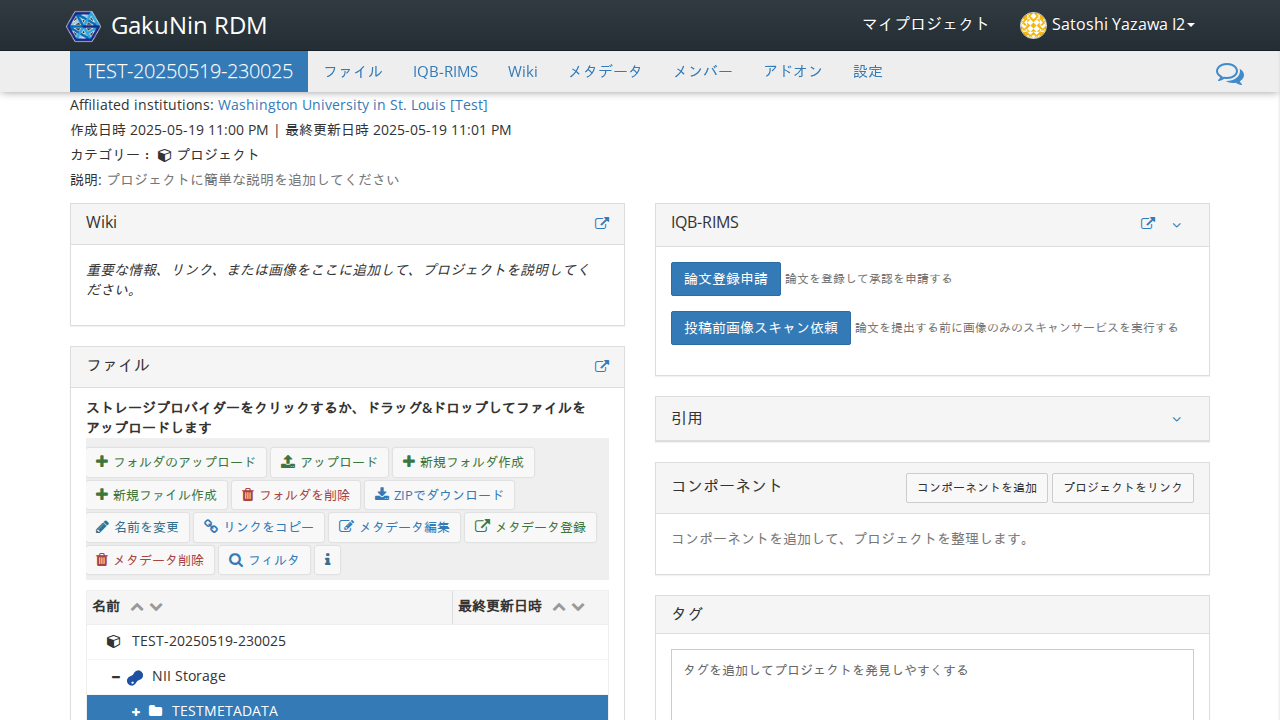

In [ ]:
async def _step(page):
    await page.locator('//*[text() = "TESTMETADATA"]').click()
    await expect(page.locator('//*[text() = "メタデータ登録"]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

##  「メタデータ登録」をクリックする

「ファイルメタデータ登録先の選択」ダイアログが表示され、「サンプルメタデータプロジェクト」とチェックボックスが表示されること

Start epoch: 1747695706.9386935 seconds


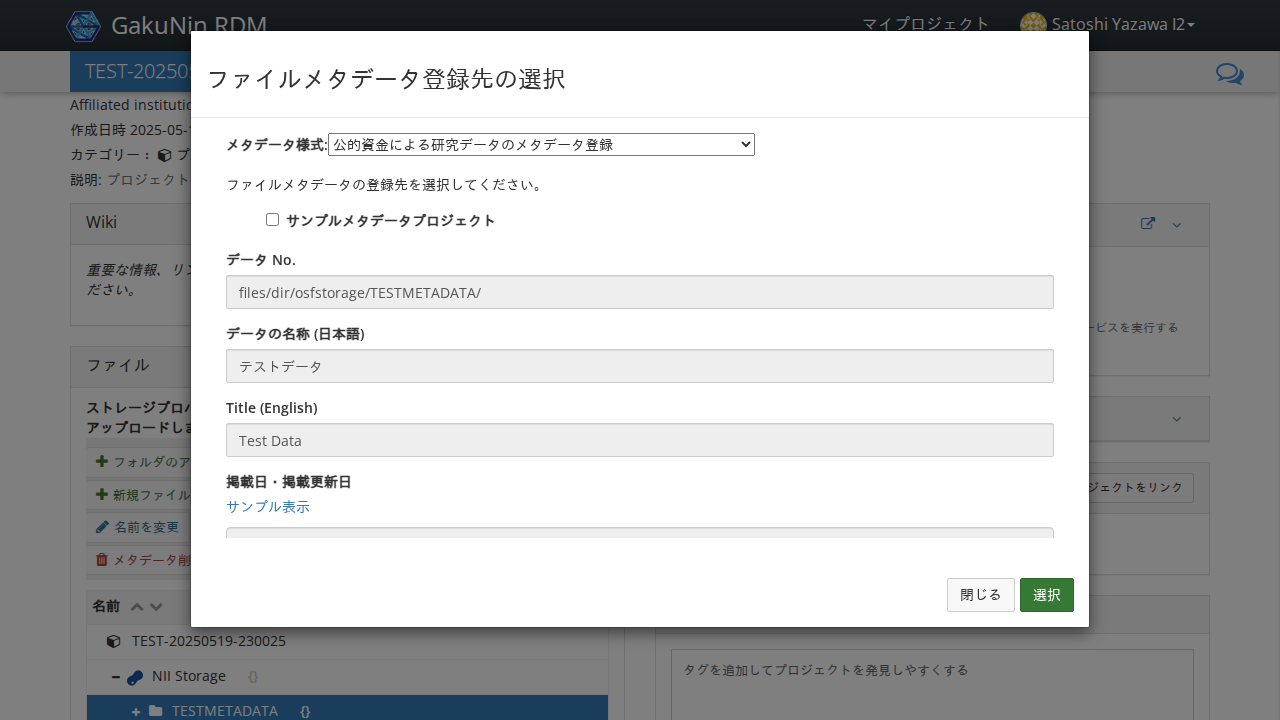

In [78]:
async def _step(page):
    await page.locator('//*[text() = "メタデータ登録"]').click()
    await expect(page.locator('//input[starts-with(@id, "draft-")]')).to_have_count(1, timeout=transition_timeout)

await run_pw(_step)

##  「サンプルメタデータプロジェクト」をクリックする

チェックボックスがチェック状態になること

Start epoch: 1747695708.0541425 seconds


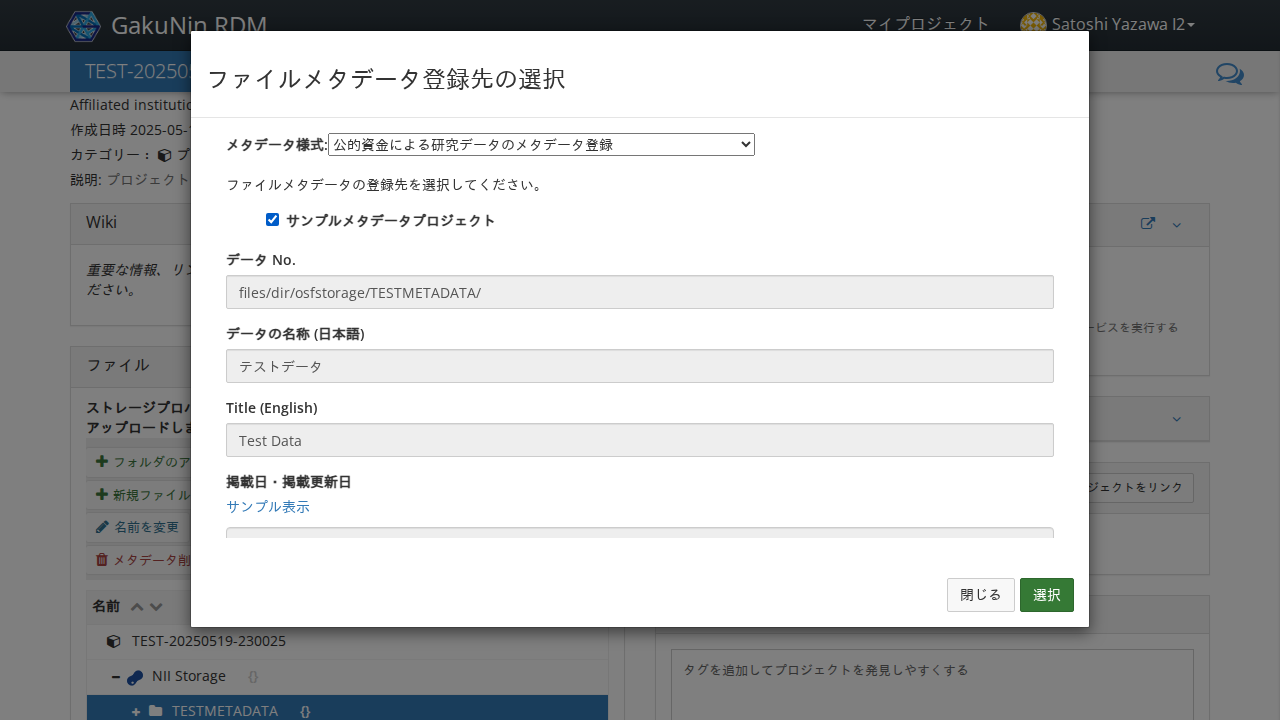

In [79]:
async def _step(page):
    checkbox = page.locator('//input[starts-with(@id, "draft-")]')
    await checkbox.click()
    await expect(checkbox).to_be_checked(timeout=transition_timeout)

await run_pw(_step)

##  「選択」をクリックする

「サンプルメタデータプロジェクト」に「開く」リンクが現れること

Start epoch: 1747695708.3065653 seconds


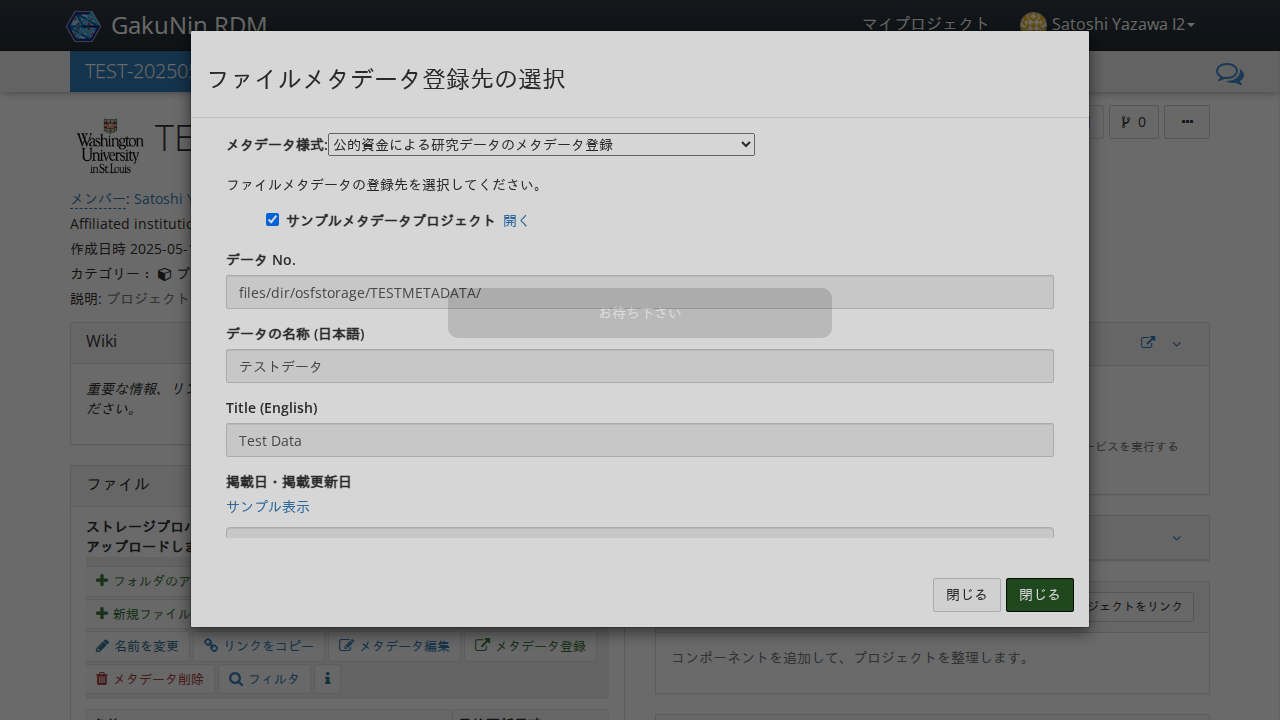

In [80]:
async def _step(page):
    await page.locator('//*[text() = "選択"]').click()
    await expect(page.locator('//*[text() = "開く"]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 「開く」をクリックする

ワークフローメタデータ編集画面が表示され、登録データ一覧に「テストデータ」が表示されること

Start epoch: 1747695708.9367335 seconds


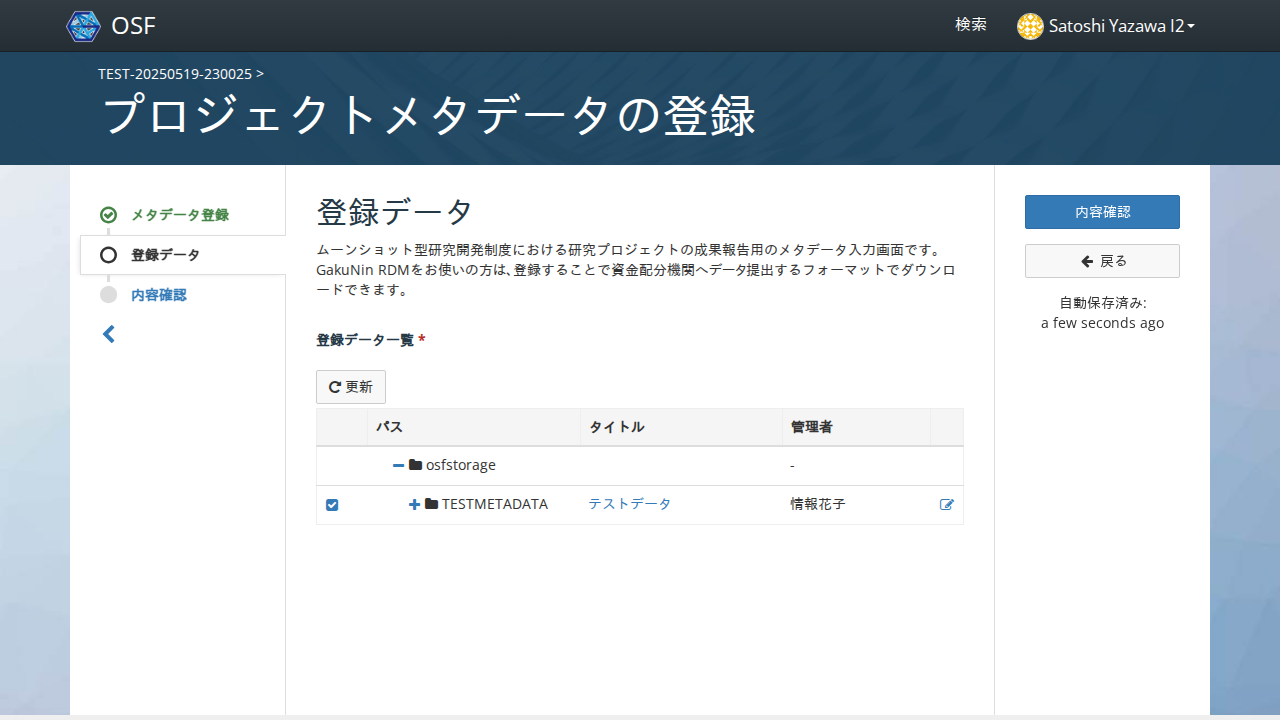

In [ ]:
async def _step(page):
    await page.locator('//*[text() = "開く"]').click()
    await expect(page.locator('//*[@data-test-goto-review]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「内容確認」をクリックする

左側ペイン「登録データ」が緑色かつチェックマークが表示されること

Start epoch: 1747695712.885344 seconds


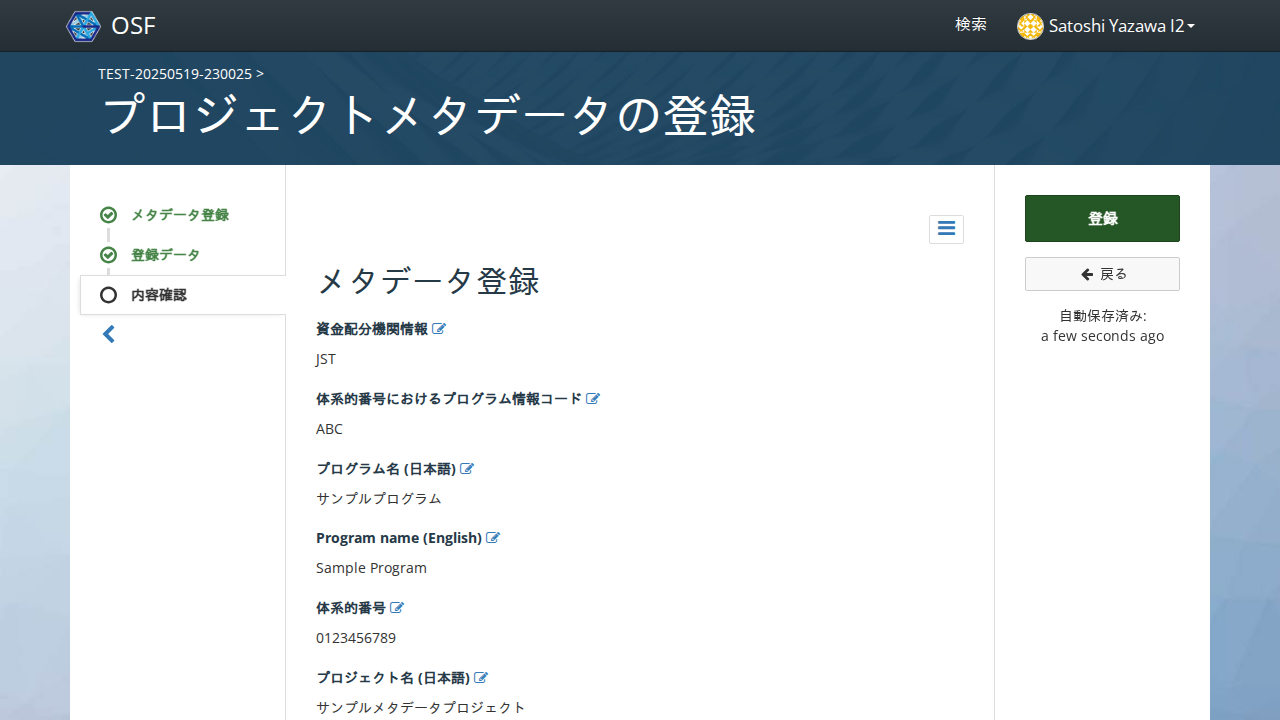

In [82]:
async def _step(page):
    await page.locator('//*[@data-test-goto-review]').click()
    
    await expect(page.locator('//span[@data-test-label and text() = "登録データ"]/../preceding-sibling::i')).to_have_class(re.compile(r'.*fa-check-circle-o.*'), timeout=transition_timeout)

await run_pw(_step)

## 「エクスポート」をクリックする

言語選択画面が表示されること

Start epoch: 1747695713.2257626 seconds


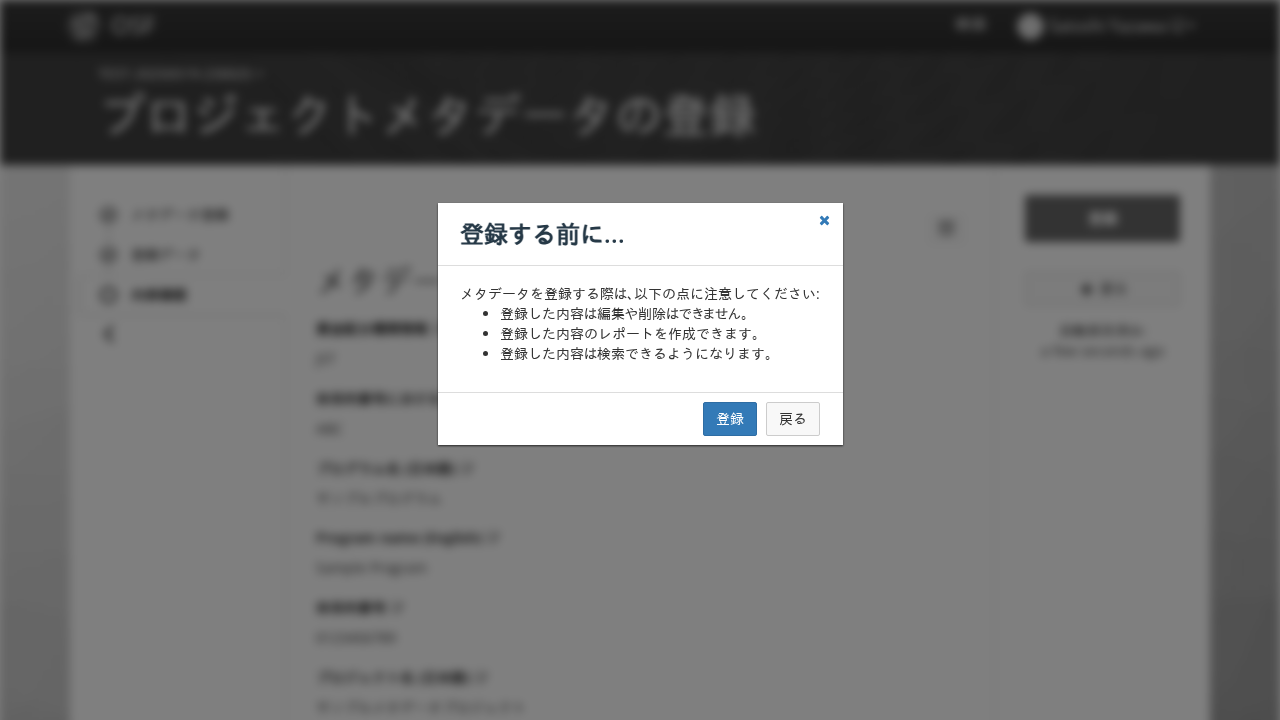

In [ ]:
async def _step(page):
    await page.locator('//button[@data-test-registration-card-export]').click()
    
    await expect(page.locator('//select[@id = "registration-report-format-selection"]')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)

## 「メタデータ共通項目2024版CSV形式 (日本語)」を選択し「エクスポート」をクリックする

CSVファイルがダウンロードされ、かつ、このCSVはUTF-16 BOM付きファイルで2行のファイルとなっていること。
データの分野が「情報通信」となっていること

In [ ]:
import pandas as pd

async def _step(page):
    await page.locator('//select[@id = "registration-report-format-selection"]').select_option('メタデータ共通項目2024版CSV形式 (日本語)')
    download_future = page.wait_for_event('download')
    await page.locator('//button[@data-test-registration-report-submit]').click()
    download = await download_future
    await download.save_as(os.path.join(work_dir, 'report.csv'))
    assert os.path.exists(os.path.join(work_dir, 'report.csv'))
    df = pd.read_csv(os.path.join(work_dir, 'report.csv'), encoding='utf-16')
    assert '資金配分機関情報' in df.columns
await run_pw(_step)

## 画面上部「プロジェクトメタデータ一覧」をクリックする

メタデータ一覧画面が表示されること

Start epoch: 1747695714.8444734 seconds


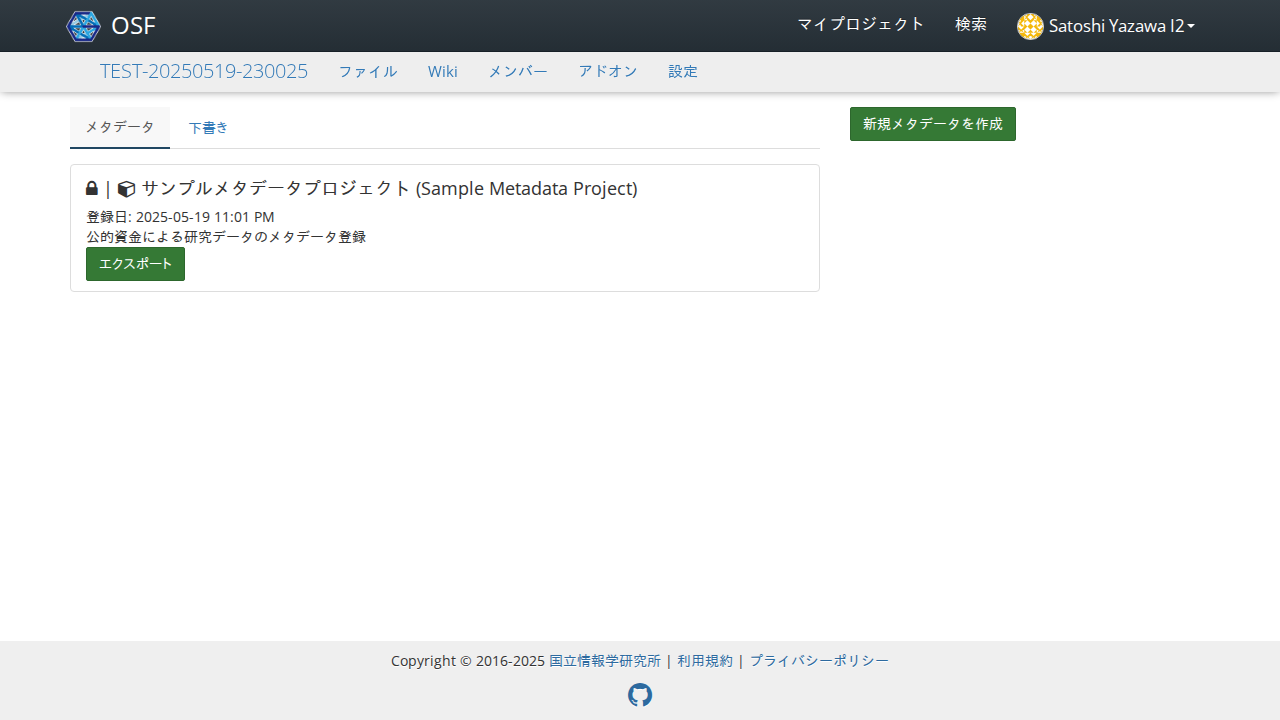

In [ ]:
async def _step(page):
    await page.locator('//a[text()="プロジェクトメタデータ一覧"]').click()
    await expect(page.locator('//button[@data-test-registration-card-export]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 「エクスポート」をクリックする

言語選択画面が表示されること

Start epoch: 1747695718.9574325 seconds


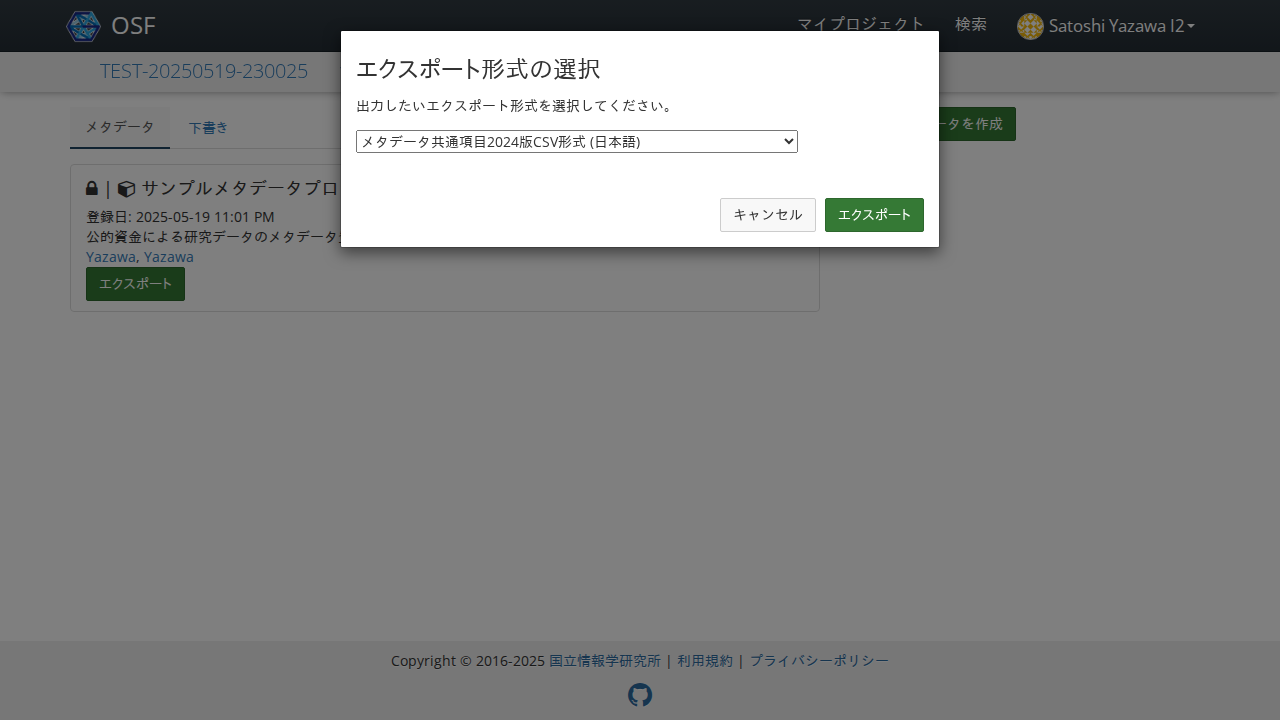

In [85]:
async def _step(page):
    await page.locator('//button[@data-test-registration-card-export]').click()
    
    await expect(page.locator('//select[@id = "registration-report-format-selection"]')).to_be_enabled(timeout=30000)
    time.sleep(1)

await run_pw(_step)

## 「メタデータ共通項目2024版CSV形式 (日本語)」を選択し「エクスポート」をクリックする

CSVファイルがダウンロードされ、かつ、このCSVはUTF-16 BOM付きファイルで2行のファイルとなっていること。
データの分野が「情報通信」となっていること

Start epoch: 1747695720.2057693 seconds


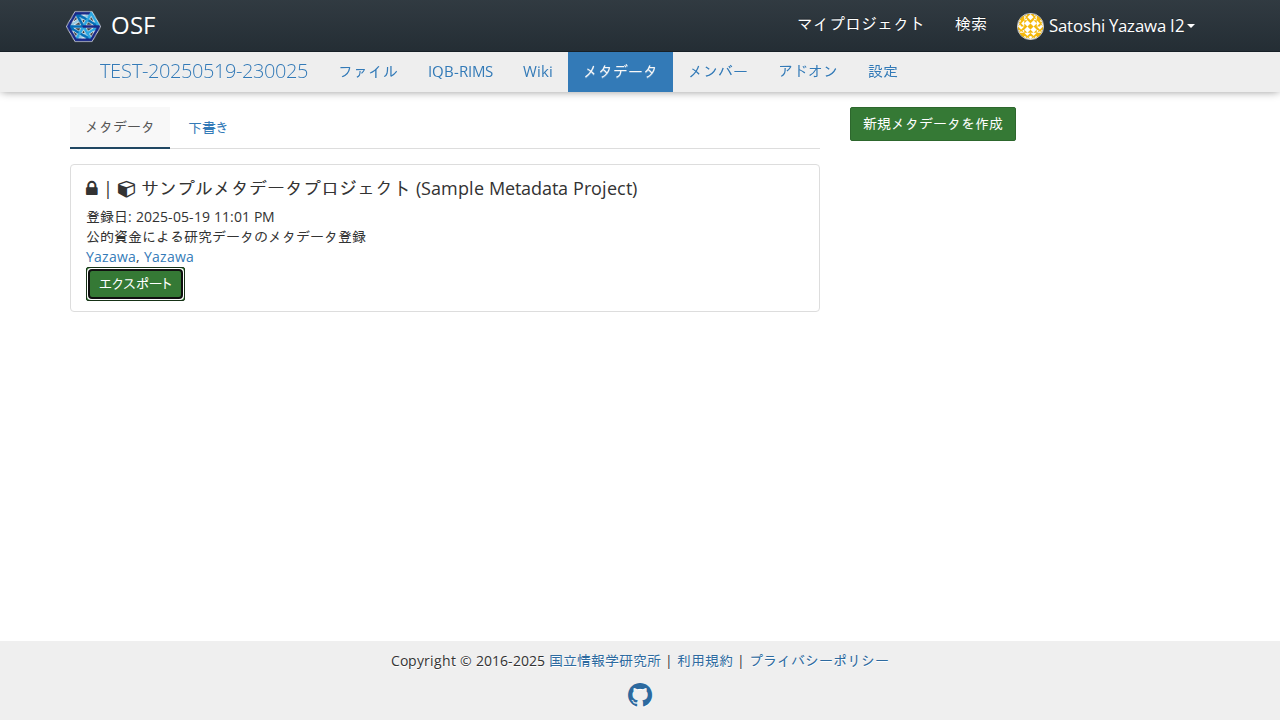

In [86]:
async def _step(page):
    await page.locator('//select[@id = "registration-report-format-selection"]').select_option('メタデータ共通項目2024版CSV形式 (日本語)')
    download_future = page.wait_for_event('download')
    await page.locator('//button[@data-test-registration-report-submit]').click()
    download = await download_future
    await download.save_as(os.path.join(work_dir, 'report.csv'))
    assert os.path.exists(os.path.join(work_dir, 'report.csv'))

await run_pw(_step)

In [87]:
import pandas as pd
df = pd.read_csv(os.path.join(work_dir, 'report.csv'), encoding='utf-16')
df

In [ ]:
import re
import numpy as np

assert_values = {
    '資金配分機関情報': '国立研究開発法人科学技術振興機構',
    '体系的番号におけるプログラム情報コード': 'ABC',
    'プログラム名': 'サンプルプログラム',
    '体系的番号': 123456789,
    'プロジェクト名': 'サンプルメタデータプロジェクト',
    'データNo.': f'files/dir/{target_storage_id}/TESTMETADATA/',
    'データの名称': 'テストデータ',
    '掲載日・掲載更新日': '2022-05-25',
    'データの説明': '自動テストによって作成されたメタデータです。',
    'データの分野': '情報通信',
    'データ種別': 'データセット',
    '概略データ量': '0B',
    '管理対象データの利活用・提供方針 (有償/無償)': '無償',
    '管理対象データの利活用・提供方針(ライセンス)': 'CCBY',
    '管理対象データの利活用・提供方針(引用方法等)': '利用方針をここに記載します。',
    'アクセス権': '公開',
    '公開予定日 (公開期間猶予の場合)': np.nan,
    'リポジトリ情報': 'テストリポジトリ',
    'リポジトリURL・DOIリンク': re.compile(r'https?:\/\/[^\/]+\/[^\/]+\/files\/dir\/' + target_storage_id + r'\/TESTMETADATA\/'),
    'データ作成者': '情報太郎',
    'データ作成者の研究者番号': 123456789,
    'データ管理機関': '国立情報学研究所',
    'データ管理機関コード': 'https://ror.org/DUMMY',
    'データ管理者': '情報花子',
    'データ管理者の研究者番号': 123456789,
    'データ管理者の所属組織名': 'テストセンター',
    'データ管理者の所属機関の連絡先住所': 'テスト住所',
    'データ管理者の所属機関の連絡先電話番号': '000-0000-0000',
    'データ管理者の所属機関の連絡先メールアドレス': 'test@test.nii.ac.jp',
    '備考': '日本語による備考です。'
}
for column in ['資金配分機関情報',
 '体系的番号におけるプログラム情報コード',
 'プログラム名',
 '体系的番号',
 'プロジェクト名',
 'データNo.',
 'データの名称',
 '掲載日・掲載更新日',
 'データの説明',
 'データの分野',
 'データ種別',
 '概略データ量',
 '管理対象データの利活用・提供方針 (有償/無償)',
 '管理対象データの利活用・提供方針(ライセンス)',
 '管理対象データの利活用・提供方針(引用方法等)',
 'アクセス権',
 '公開予定日 (公開期間猶予の場合)',
 'リポジトリ情報',
 'リポジトリURL・DOIリンク',
 'データ作成者',
 'データ作成者の研究者番号',
 'データ管理機関',
 'データ管理機関コード',
 'データ管理者',
 'データ管理者の研究者番号',
 'データ管理者の所属組織名',
 'データ管理者の所属機関の連絡先住所',
 'データ管理者の所属機関の連絡先電話番号',
 'データ管理者の所属機関の連絡先メールアドレス',
 '備考']:
    assert column in assert_values, (column)
    if isinstance(assert_values[column], float) and np.isnan(assert_values[column]):
        assert np.isnan(df[column].values[0]), (column, assert_values[column], df[column].values[0])
        continue
    if hasattr(assert_values[column], 'match'):
        assert assert_values[column].match(df[column].values[0]), (column, assert_values[column], df[column].values[0])
        continue
    assert df[column].values[0] == assert_values[column], (column, assert_values[column], df[column].values[0])

In [89]:
!rm {work_dir}/report.csv

## 「エクスポート」をクリックする

言語選択画面が表示されること

Start epoch: 1747695720.8790734 seconds


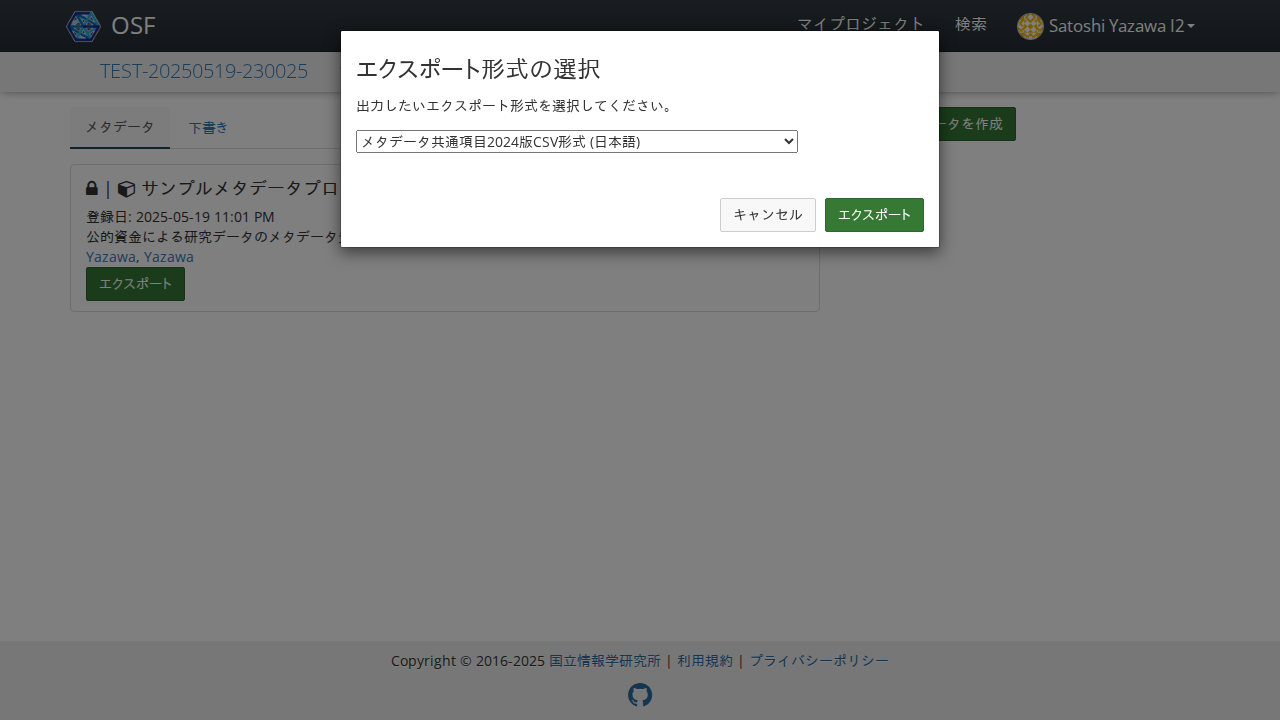

In [ ]:
async def _step(page):
    await page.locator('//button[@data-test-registration-card-export]').click()
    
    await expect(page.locator('//select[@id = "registration-report-format-selection"]')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)

## 「Common Metadata Elements 2024 edition CSV format (English)」を選択し「エクスポート」をクリックする

CSVファイルがダウンロードされ、かつ、このCSVはUTF-16 BOM付きファイルで2行のファイルとなっていること。
Research fieldが「Informatics」となっていること

Start epoch: 1747695722.0942402 seconds


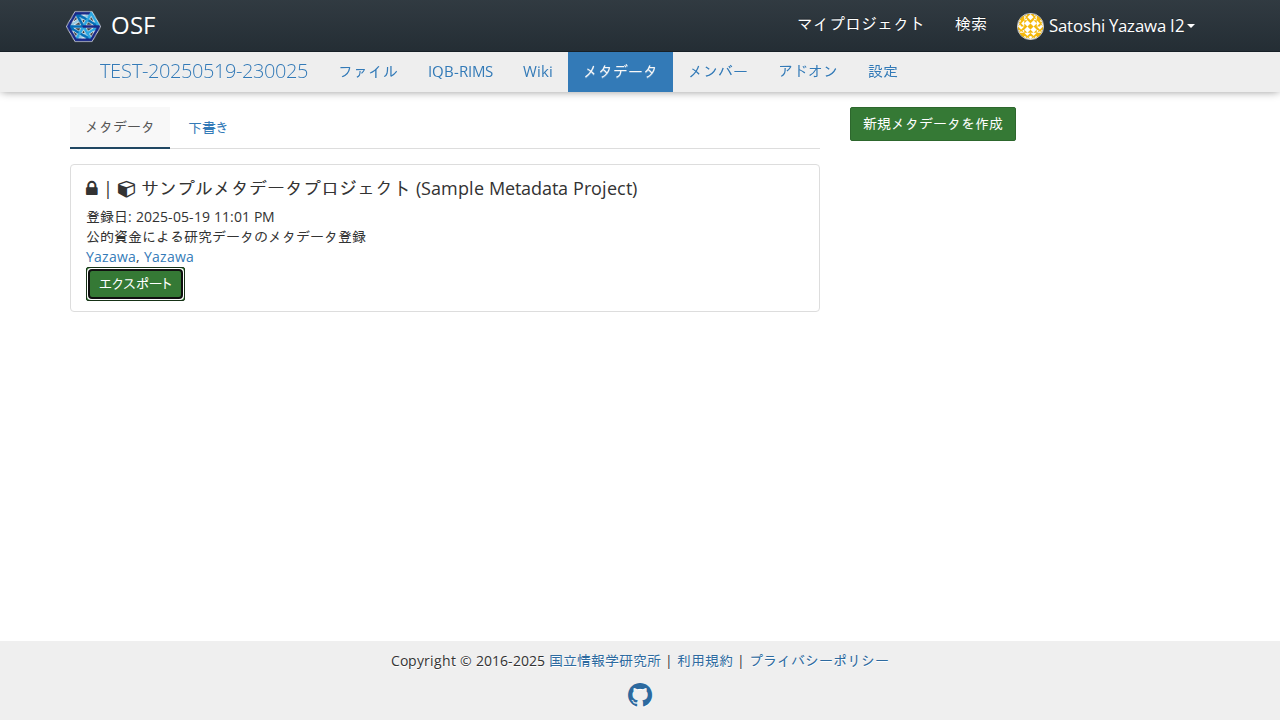

In [91]:
async def _step(page):
    await page.locator('//select[@id = "registration-report-format-selection"]').select_option('Common Metadata Elements 2024 edition CSV format (English)')
    download_future = page.wait_for_event('download')
    await page.locator('//button[@data-test-registration-report-submit]').click()
    download = await download_future
    await download.save_as(os.path.join(work_dir, 'report.csv'))
    assert os.path.exists(os.path.join(work_dir, 'report.csv'))

await run_pw(_step)

In [92]:
import pandas as pd
df = pd.read_csv(os.path.join(work_dir, 'report.csv'), encoding='utf-16')
df

In [93]:
list(df.columns)

['Funder',
 'Funding stream code in Japan Grant Number',
 'Program name',
 'Japan Grant Number',
 'Project name',
 'Data No.',
 'Title',
 'Date (Issued / Updated)',
 'Description',
 'Research field',
 'Data type',
 'File size',
 'Data utilization and provision policy(Free/Consideration)',
 'Data utilization and provision policy(License)',
 'Data utilization and provision policy(citation information)',
 'Access rights',
 'Publication date (for embargoed access)',
 'Repository information',
 'Repository URL/ DOI link',
 'Creator Name',
 'Creator name identifier (e-Rad)',
 'Hosting institution',
 'Hosting institution Identifier',
 'Data manager',
 'Data manager identifier (e-Rad)',
 'Contact organization of data manager',
 'Contact address of data manager',
 'Contact phone number of data manager',
 'Contact mail address of data manager',
 'Remarks']

In [ ]:
import re
import numpy as np

assert_values = {
    'Funder': 'Japan Science and Technology Agency',
    'Funding stream code in Japan Grant Number': 'ABC',
    'Program name': 'Sample Program',
    'Japan Grant Number': 123456789,
    'Project name': 'Sample Metadata Project',
    'Data No.': f'files/dir/{target_storage_id}/TESTMETADATA/',
    'Title': 'Test Data',
    'Date (Issued / Updated)': '2022-05-25',
    'Description': 'Metadata created by automated testing.',
    'Research field': 'Informatics',
    'Data type': 'dataset',
    'File size': '0B',
    'Data utilization and provision policy(Free/Consideration)': 'free',
    'Data utilization and provision policy(License)': 'CCBY',
    'Data utilization and provision policy(citation information)': 'The policy for use is described here.',
    'Access rights': 'open access',
    'Publication date (for embargoed access)': np.nan,
    'Repository information': 'Test Repository',
    'Repository URL/ DOI link': re.compile(r'https?:\/\/[^\/]+\/[^\/]+\/files\/dir\/' + target_storage_id + r'\/TESTMETADATA\/'),
    'Creator Name': 'Taro Joho',
    'Creator name identifier (e-Rad)': 123456789,
    'Hosting institution': 'National Institute of Informatics',
    'Hosting institution Identifier': 'https://ror.org/DUMMY',
    'Data manager': 'Hanako Joho',
    'Data manager identifier (e-Rad)': 123456789,
    'Contact organization of data manager': 'Test Center',
    'Contact address of data manager': 'Test Address',
    'Contact phone number of data manager': '000-0000-0000',
    'Contact mail address of data manager': 'test@test.nii.ac.jp',
    'Remarks': 'Remarks in English.'
}
for column in ['Funder',
 'Funding stream code in Japan Grant Number',
 'Program name',
 'Japan Grant Number',
 'Project name',
 'Data No.',
 'Title',
 'Date (Issued / Updated)',
 'Description',
 'Research field',
 'Data type',
 'File size',
 'Data utilization and provision policy(Free/Consideration)',
 'Data utilization and provision policy(License)',
 'Data utilization and provision policy(citation information)',
 'Access rights',
 'Publication date (for embargoed access)',
 'Repository information',
 'Repository URL/ DOI link',
 'Creator Name',
 'Creator name identifier (e-Rad)',
 'Hosting institution',
 'Hosting institution Identifier',
 'Data manager',
 'Data manager identifier (e-Rad)',
 'Contact organization of data manager',
 'Contact address of data manager',
 'Contact phone number of data manager',
 'Contact mail address of data manager',
 'Remarks']:
    assert column in assert_values, (column)
    if isinstance(assert_values[column], float) and np.isnan(assert_values[column]):
        assert np.isnan(df[column].values[0]), (column, assert_values[column], df[column].values[0])
        continue
    if hasattr(assert_values[column], 'match'):
        assert assert_values[column].match(df[column].values[0]), (column, assert_values[column], df[column].values[0])
        continue
    assert df[column].values[0] == assert_values[column], (column, assert_values[column], df[column].values[0])

In [95]:
!rm {work_dir}/report.csv

## (指定がある場合) プロジェクトを削除する

1つ前のウィンドウに戻り、プロジェクトを削除する。

Start epoch: 1747695725.019331 seconds
Banneker


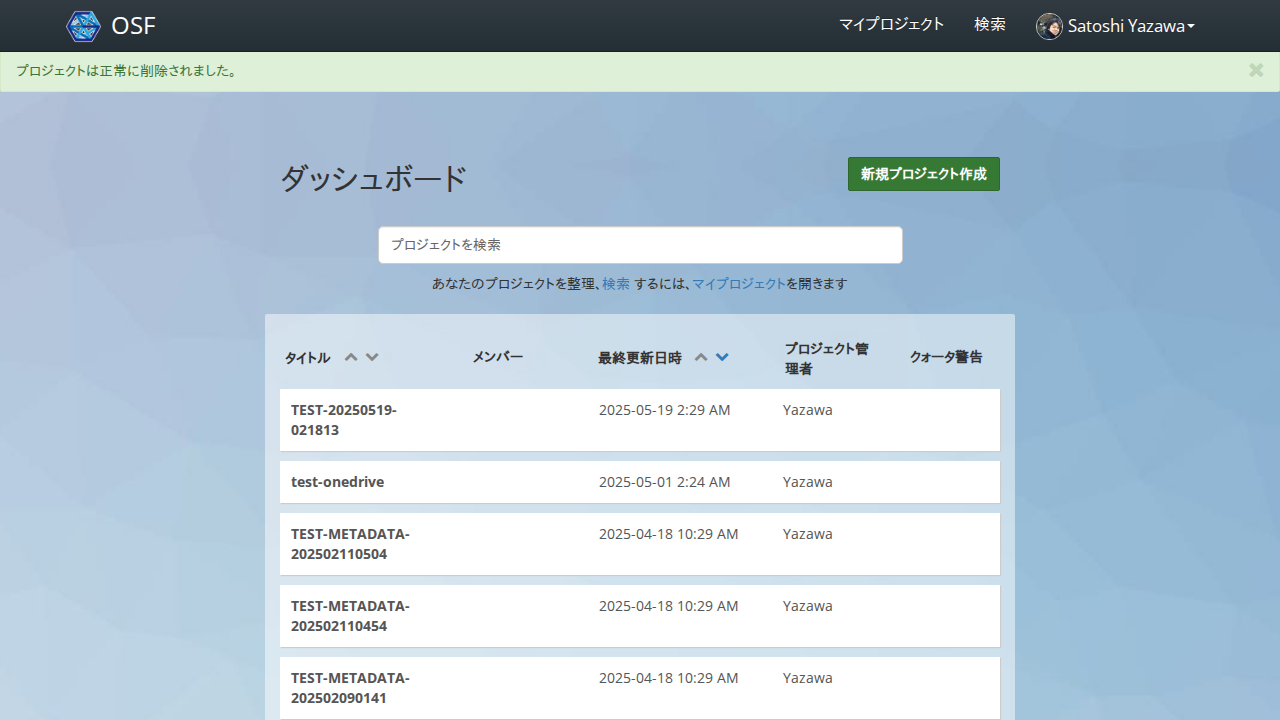

In [96]:
await close_latest_page()
await close_latest_page()

async def _step(page):
    if not delete_project:
        return
    await scripts.grdm.delete_project(page)
    
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

終了処理を実施。

In [97]:
await finish_pw_context()

Video: /tmp/tmpxw46nyji/video-1.webm
HAR: /tmp/tmpxw46nyji/har.zip


スクリーンキャプチャ動画の取得に失敗しました。
Traceback (most recent call last):
  File "/home/jovyan/scripts/playwright.py", line 168, in _finish_pw_context
    shutil.copyfile(video_path, dest_video_path)
  File "/opt/conda/lib/python3.12/shutil.py", line 260, in copyfile
    with open(src, 'rb') as fsrc:
         ^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/tmp/tmpwzy4kfyr/videos/a83635a0ae1399ec92170a9810cf57a3.webm'


In [98]:
!rm -fr {work_dir}